## 2. Data Loading & Preprocessing

In [1]:
import pandas as pd

TRAIN_FILE = "data/train.csv"
TEST_FILE = "data/phase_1_test.csv"


df_train = pd.read_csv(TRAIN_FILE)
display(df_train.head())
print(f"✓ Loaded {len(df_train)} training samples")
print(f"Columns: {df_train.columns.tolist()}")
print(f"\nFirst sample:")
print(f"Question preview: {df_train['question'].iloc[0][:200]}...")
print(f"Answer: {df_train['answer'].iloc[0]}")
print(f"\nAnswer distribution:")
print(df_train['answer'].value_counts())

,ID,question,answer
0,ID_1P7PJMPV0R,Analyze the 5G wireless network drive-test use...,C2
1,ID_8B1D1TUTFA,Analyze the 5G wireless network drive-test use...,C1
2,ID_IGGXMA9GZH,Analyze the 5G wireless network drive-test use...,C2
3,ID_D6C9N2X295,Analyze the 5G wireless network drive-test use...,C2
4,ID_8JC15PNP3Q,Analyze the 5G wireless network drive-test use...,C5


✓ Loaded 2400 training samples
Columns: ['ID', 'question', 'answer']

First sample:
Question preview: Analyze the 5G wireless network drive-test user plane data and engineering parameters.
Identify the reason for the throughput dropping below 600Mbps in certain road sections.
From the following 8 pote...
Answer: C2

Answer distribution:
answer
C5    352
C7    349
C3    330
C2    320
C4    283
C8    277
C1    264
C6    225
Name: count, dtype: int64


## 📊 Enhanced Preprocessing with Type Safety & Feature Engineering

**Key Improvements:**
1. ✅ **Type casting** - Ensures all numeric fields are properly typed (not strings)
2. ✅ **Missing neighbor RSRP fields** - Now included in float casting
3. ✅ **Centralized field definitions** - Easy to maintain
4. ✅ **RCA-friendly features** - Computed automatically for better model learning

**Why This Matters:**
- Prevents "123.4" string vs 123.4 float bugs in calculations
- Ensures distance/ratio computations work correctly
- Makes feature engineering more reliable

In [2]:
import re
import json
import math
import pandas as pd
from statistics import mean, median, stdev
from typing import List, Dict, Any, Optional

# ============================================================================
# LABEL MAPPING
# ============================================================================
CAUSE_TO_NUM = {f"C{i}": i for i in range(1, 9)}
NUM_TO_CAUSE = {i: f"C{i}" for i in range(1, 9)}

# ============================================================================
# TYPE CONVERSION UTILITIES
# ============================================================================

def to_float(x) -> Optional[float]:
    """Safely convert to float, handling None, '-', and invalid values"""
    if x is None or x == "" or x == "-" or x == "—":
        return None
    try:
        return float(x)
    except (ValueError, TypeError):
        return None

def to_int(x) -> Optional[int]:
    """Safely convert to int, handling None, '-', and invalid values"""
    if x is None or x == "" or x == "-" or x == "—":
        return None
    try:
        return int(float(x))  # float first to handle "123.0" strings
    except (ValueError, TypeError):
        return None

def sanitize_question_text(q: str) -> str:
    """
    Convert literal '\\n' to real newlines.
    CRITICAL: Don't use unicode decoding or you corrupt '\\boxed'
    """
    if q is None:
        return ""
    return q.replace("\\n", "\n").replace("\r\n", "\n").replace("\r", "\n")

# ============================================================================
# DOMAIN-SPECIFIC CALCULATIONS
# ============================================================================

def haversine_m(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Calculate distance in meters between two lat/lon points"""
    R = 6371000.0  # Earth radius in meters
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlmb/2)**2
    return 2 * R * math.asin(math.sqrt(a))

def beamwidth_deg(beam_scenario: str) -> int:
    """
    Map beam scenario to vertical beamwidth:
    - DEFAULT/SCENARIO_1-5: 6 degrees
    - SCENARIO_6-11: 12 degrees
    - SCENARIO_12+: 25 degrees
    """
    s = (beam_scenario or "").upper().strip()
    if s == "DEFAULT":
        return 6

    m = re.match(r"SCENARIO_(\d+)", s)
    if not m:
        return 6

    k = int(m.group(1))
    if 1 <= k <= 5:
        return 6
    elif 6 <= k <= 11:
        return 12
    else:  # 12+
        return 25

def electronic_tilt_deg(digital_tilt) -> float:
    """
    Convert digital tilt to degrees:
    - 255 => 6 degrees (special case)
    - Otherwise: value is degrees
    """
    try:
        v = int(float(digital_tilt))
        return 6.0 if v == 255 else float(v)
    except (ValueError, TypeError):
        return 6.0  # Default fallback

print("✓ Type conversion and domain utilities loaded")

✓ Type conversion and domain utilities loaded


In [3]:
# ============================================================================
# TABLE PARSING
# ============================================================================

def parse_pipe_table(table_text: str) -> List[Dict[str, Any]]:
    """
    Parse pipe-delimited table into list of dicts.
    Handles '-', '—', and empty values as None.
    """
    if not table_text:
        return []

    lines = [ln.strip() for ln in table_text.splitlines() if ln.strip()]
    lines = [ln for ln in lines if "|" in ln]

    if not lines:
        return []

    # Parse header
    header = [h.strip() for h in lines[0].split("|")]

    # Parse rows
    rows = []
    for ln in lines[1:]:
        parts = [p.strip() for p in ln.split("|")]

        # Normalize row length to match header
        if len(parts) < len(header):
            parts += [""] * (len(header) - len(parts))
        elif len(parts) > len(header):
            parts = parts[:len(header)]

        # Build record
        rec = {}
        for k, v in zip(header, parts):
            rec[k] = None if v in ("", "-", "—", "–") else v

        rows.append(rec)

    return rows

print("✓ Table parsing loaded")

✓ Table parsing loaded


In [4]:
# ============================================================================
# COLUMN MAPPING & TYPE CASTING (IMPROVED)
# ============================================================================

# Drive-test data column mappings
DRIVE_MAP = {
    "Timestamp": "timestamp",
    "Longitude": "longitude",
    "Latitude": "latitude",
    "GPS Speed (km/h)": "gps_speed_kmh",
    "5G KPI PCell RF Serving PCI": "serving_pci",
    "5G KPI PCell RF Serving SS-RSRP [dBm]": "ss_rsrp_dbm",
    "5G KPI PCell RF Serving SS-SINR [dB]": "ss_sinr_db",
    "5G KPI PCell Layer2 MAC DL Throughput [Mbps]": "throughput_mbps",
    "5G KPI PCell Layer1 DL RB Num (Including 0)": "dl_rb_num",

    # Neighbor PCIs
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI": "nei1_pci",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI": "nei2_pci",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI": "nei3_pci",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI": "nei4_pci",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI": "nei5_pci",

    # Neighbor RSRPs (CRITICAL - these were missing!)
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]": "nei1_rsrp_dbm",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm]": "nei2_rsrp_dbm",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]": "nei3_rsrp_dbm",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]": "nei4_rsrp_dbm",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]": "nei5_rsrp_dbm",
}

# Engineering parameters column mappings
ENG_MAP = {
    "gNodeB ID": "gnodeb_id",
    "Cell ID": "cell_id",
    "Longitude": "longitude",
    "Latitude": "latitude",
    "Mechanical Azimuth": "mechanical_azimuth",
    "Mechanical Downtilt": "mechanical_downtilt",
    "Digital Tilt": "digital_tilt",
    "Digital Azimuth": "digital_azimuth",
    "Beam Scenario": "beam_scenario",
    "Height": "height",
    "PCI": "pci",
    "TxRx Mode": "txrx_mode",
    "Max Transmit Power": "max_tx_power",
    "Antenna Model": "antenna_model",
}

# Define fields by type for proper casting
FLOAT_FIELDS = [
    "longitude", "latitude", "gps_speed_kmh",
    "ss_rsrp_dbm", "ss_sinr_db", "throughput_mbps", "dl_rb_num",
    "mechanical_downtilt", "digital_tilt", "height", "max_tx_power",
    "mechanical_azimuth", "digital_azimuth",
    # CRITICAL: Add neighbor RSRP fields
    "nei1_rsrp_dbm", "nei2_rsrp_dbm", "nei3_rsrp_dbm",
    "nei4_rsrp_dbm", "nei5_rsrp_dbm",
]

INT_FIELDS = [
    "pci", "serving_pci",
    "nei1_pci", "nei2_pci", "nei3_pci", "nei4_pci", "nei5_pci",
]

def normalize_rows(rows: List[Dict], mapping: Dict[str, str]) -> List[Dict]:
    """
    Normalize column names and apply type casting.
    This ensures all numeric operations work correctly.
    """
    normalized = []

    for r in rows:
        nr = {}

        # Map column names
        for k, v in r.items():
            normalized_key = mapping.get(k)
            if normalized_key is None:
                continue  # Skip unmapped columns
            nr[normalized_key] = v

        # Type casting - CRITICAL for numeric operations
        for field in FLOAT_FIELDS:
            if field in nr:
                nr[field] = to_float(nr[field])

        for field in INT_FIELDS:
            if field in nr:
                nr[field] = to_int(nr[field])

        normalized.append(nr)

    return normalized

print("✓ Column mappings and type casting configured")
print(f"  - Float fields: {len(FLOAT_FIELDS)}")
print(f"  - Int fields: {len(INT_FIELDS)}")
print(f"  - Drive-test columns mapped: {len(DRIVE_MAP)}")
print(f"  - Engineering columns mapped: {len(ENG_MAP)}")

✓ Column mappings and type casting configured
  - Float fields: 18
  - Int fields: 7
  - Drive-test columns mapped: 19
  - Engineering columns mapped: 14


In [67]:
# ============================================================================
# RCA-FRIENDLY FEATURE ENGINEERING
# ============================================================================

from typing import List, Dict, Any
import math
from statistics import mean, median, stdev

def compute_rca_features(drive_rows: List[Dict], eng_rows: List[Dict]) -> Dict[str, Any]:
    """
    Compute derived features that help the model learn root cause patterns.
    This is the KEY to good RCA performance!

    Returns dict with all computed features.

    NOTE: Per your request, NOTHING from your original function is removed.
    Only NEW features are appended (mostly stronger C4 discriminators).
    """
    features = {}

    # -------------------------------------------------------------------------
    # A) Throughput-drop signature (C8 indicator) + EFFICIENCY ANALYSIS (C3-A)
    # -------------------------------------------------------------------------
    tps = [r["throughput_mbps"] for r in drive_rows if r.get("throughput_mbps") is not None]

    if tps:
        features["tp_min_mbps"] = min(tps)
        features["tp_mean_mbps"] = mean(tps)
        features["tp_max_mbps"] = max(tps)
        features["tp_drop_ratio"] = sum(1 for x in tps if x < 600) / len(tps)
        features["tp_samples_below_600"] = sum(1 for x in tps if x < 600)
    else:
        features["tp_min_mbps"] = None
        features["tp_mean_mbps"] = None
        features["tp_max_mbps"] = None
        features["tp_drop_ratio"] = None
        features["tp_samples_below_600"] = 0

    # -------------------------------------------------------------------------
    # B) Resource constraint (C8) + EFFICIENCY (C3-A)
    # -------------------------------------------------------------------------
    rbs = [r["dl_rb_num"] for r in drive_rows if r.get("dl_rb_num") is not None]

    if rbs:
        features["rb_mean"] = mean(rbs)
        features["rb_min"] = min(rbs)
        features["rb_max"] = max(rbs)
        features["rb_below_160_flag"] = features["rb_mean"] < 160 if features["rb_mean"] else False
    else:
        features["rb_mean"] = None
        features["rb_min"] = None
        features["rb_max"] = None
        features["rb_below_160_flag"] = False
    
    # NEW: Throughput Efficiency Ratio (C3-A) - SERVING CELL
    # Efficiency = throughput per RB (accounts for scheduling/load)
    tp_rb_pairs = [(r.get("throughput_mbps"), r.get("dl_rb_num")) 
                   for r in drive_rows 
                   if r.get("throughput_mbps") is not None and r.get("dl_rb_num") is not None and r.get("dl_rb_num") > 0]
    
    if tp_rb_pairs:
        efficiencies = [tp / rb for tp, rb in tp_rb_pairs]
        features["throughput_efficiency_mbps_per_rb"] = mean(efficiencies)
        features["throughput_efficiency_min"] = min(efficiencies)
        features["throughput_efficiency_max"] = max(efficiencies)
        
        # Low efficiency despite RBs available suggests scheduling/load issue (C3 pattern)
        # Typical good efficiency: ~7-10 Mbps/RB
        features["low_efficiency_flag"] = features["throughput_efficiency_mbps_per_rb"] < 4
    else:
        features["throughput_efficiency_mbps_per_rb"] = None
        features["throughput_efficiency_min"] = None
        features["throughput_efficiency_max"] = None
        features["low_efficiency_flag"] = False
    
    # NEW: Neighbor Throughput Efficiency (C3 discriminator)
    # Compare neighbor efficiency to detect if neighbor would provide better throughput
    neighbor_tp_eff = []
    for r in drive_rows:
        for i in range(1, 6):
            tp_key = f"nei{i}_throughput_mbps"
            rb_key = f"nei{i}_dl_rb_num"
            tp = r.get(tp_key)
            rb = r.get(rb_key)
            if tp is not None and rb is not None and rb > 0:
                neighbor_tp_eff.append(tp / rb)
    
    if neighbor_tp_eff:
        features["neighbor_tp_eff_mean"] = mean(neighbor_tp_eff)
        features["neighbor_tp_eff_max"] = max(neighbor_tp_eff)
        
        # Efficiency gap - KEY C3 discriminator
        if features["throughput_efficiency_mbps_per_rb"] is not None:
            features["tp_efficiency_gap"] = features["neighbor_tp_eff_mean"] - features["throughput_efficiency_mbps_per_rb"]
            # Positive gap = neighbor would provide better efficiency (C3 signature)
            features["neighbor_more_efficient"] = features["tp_efficiency_gap"] > 1.0
        else:
            features["tp_efficiency_gap"] = None
            features["neighbor_more_efficient"] = False
    else:
        features["neighbor_tp_eff_mean"] = None
        features["neighbor_tp_eff_max"] = None
        features["tp_efficiency_gap"] = None
        features["neighbor_more_efficient"] = False

    # -------------------------------------------------------------------------
    # C) Speed rule (C7)
    # -------------------------------------------------------------------------
    speeds = [r["gps_speed_kmh"] for r in drive_rows if r.get("gps_speed_kmh") is not None]

    if speeds:
        features["speed_max_kmh"] = max(speeds)
        features["speed_mean_kmh"] = mean(speeds)
        features["speed_above_40_flag"] = features["speed_max_kmh"] > 40 if features["speed_max_kmh"] else False
    else:
        features["speed_max_kmh"] = None
        features["speed_mean_kmh"] = None
        features["speed_above_40_flag"] = False

    # -------------------------------------------------------------------------
    # D) Handover / mobility (C5)
    # -------------------------------------------------------------------------
    serving_pcis = [r["serving_pci"] for r in drive_rows if r.get("serving_pci") is not None]

    handover_count = 0
    for i in range(1, len(serving_pcis)):
        if serving_pcis[i] != serving_pcis[i - 1]:
            handover_count += 1

    features["handover_count"] = handover_count
    features["frequent_handover_flag"] = handover_count >= 3  # Threshold for "frequent"

    # -------------------------------------------------------------------------
    # E) PCI mod 30 collision (C6)
    # -------------------------------------------------------------------------
    neighbor_pcis = []
    for r in drive_rows:
        for k in ["nei1_pci", "nei2_pci", "nei3_pci", "nei4_pci", "nei5_pci"]:
            v = r.get(k)
            if v is not None:
                neighbor_pcis.append(v)

    mod30_collision = False
    if serving_pcis and neighbor_pcis:
        serving_pci = serving_pcis[-1]  # Use last serving PCI
        mod30_collision = any((n % 30) == (serving_pci % 30) for n in neighbor_pcis)

    features["pci_mod30_collision"] = mod30_collision

    # -------------------------------------------------------------------------
    # F) Coverage distance / overshoot (C2)
    # -------------------------------------------------------------------------
    pci_to_cell = {c["pci"]: c for c in eng_rows if c.get("pci") is not None}

    distances = []
    for r in drive_rows:
        spci = r.get("serving_pci")
        cell = pci_to_cell.get(spci)

        if not cell:
            continue

        if (r.get("latitude") is None or r.get("longitude") is None or
            cell.get("latitude") is None or cell.get("longitude") is None):
            continue

        dist = haversine_m(
            r["latitude"], r["longitude"],
            cell["latitude"], cell["longitude"]
        )
        distances.append(dist)

    if distances:
        features["dist_median_m"] = median(distances)
        features["dist_p95_m"] = sorted(distances)[int(0.95 * (len(distances) - 1))]
        features["dist_max_m"] = max(distances)
        features["overshoot_flag"] = features["dist_p95_m"] > 1000 if features["dist_p95_m"] else False
    else:
        features["dist_median_m"] = None
        features["dist_p95_m"] = None
        features["dist_max_m"] = None
        features["overshoot_flag"] = False

    # -------------------------------------------------------------------------
    # G) Downtilt / weak far coverage (C1) + VERTICAL GEOMETRY PHYSICS
    # -------------------------------------------------------------------------
    if serving_pcis:
        cell = pci_to_cell.get(serving_pcis[-1])

        if cell:
            mech_tilt = cell.get("mechanical_downtilt") or 0.0
            elec_tilt = electronic_tilt_deg(cell.get("digital_tilt"))
            total_tilt = float(mech_tilt) + float(elec_tilt)

            vbw = beamwidth_deg(cell.get("beam_scenario", "DEFAULT"))
            tilt_to_beamwidth_ratio = total_tilt / vbw if vbw > 0 else 0.0

            features["serving_mechanical_tilt_deg"] = mech_tilt
            features["serving_electronic_tilt_deg"] = elec_tilt
            features["serving_total_tilt_deg"] = total_tilt
            features["serving_vertical_beamwidth_deg"] = vbw
            features["tilt_to_beamwidth_ratio"] = tilt_to_beamwidth_ratio
            features["large_tilt_flag"] = total_tilt > 15  # Threshold for "too large"
            
            # NEW: Vertical Geometry Mismatch (C1-A)
            # Calculate effective vertical angle based on UE position
            site_height = cell.get("site_height") or 30.0  # Default 30m if missing
            ue_height = 1.5  # Typical UE height (meters)
            
            vertical_misalignments = []
            for r in drive_rows:
                spci = r.get("serving_pci")
                if spci != serving_pcis[-1]:  # Only for samples on this serving cell
                    continue
                    
                if (r.get("latitude") is None or r.get("longitude") is None or
                    cell.get("latitude") is None or cell.get("longitude") is None):
                    continue
                
                ue_dist = haversine_m(
                    r["latitude"], r["longitude"],
                    cell["latitude"], cell["longitude"]
                )
                
                if ue_dist > 5:  # Only calculate for meaningful distances
                    # Effective vertical angle from antenna to UE
                    effective_vertical_angle = math.degrees(math.atan((site_height - ue_height) / ue_dist))
                    # Misalignment = how much tilt exceeds optimal angle
                    misalignment = total_tilt - effective_vertical_angle
                    vertical_misalignments.append(misalignment)
            
            if vertical_misalignments:
                features["vertical_misalignment_mean_deg"] = mean(vertical_misalignments)
                features["vertical_misalignment_max_deg"] = max(vertical_misalignments)
                # Large positive misalignment = UE below main beam (C1 signature)
                features["ue_below_beam_flag"] = features["vertical_misalignment_mean_deg"] > 3
            else:
                features["vertical_misalignment_mean_deg"] = None
                features["vertical_misalignment_max_deg"] = None
                features["ue_below_beam_flag"] = False
        else:
            features["serving_mechanical_tilt_deg"] = None
            features["serving_electronic_tilt_deg"] = None
            features["serving_total_tilt_deg"] = None
            features["serving_vertical_beamwidth_deg"] = None
            features["tilt_to_beamwidth_ratio"] = None
            features["large_tilt_flag"] = False
            features["vertical_misalignment_mean_deg"] = None
            features["vertical_misalignment_max_deg"] = None
            features["ue_below_beam_flag"] = False
    else:
        features["serving_mechanical_tilt_deg"] = None
        features["serving_electronic_tilt_deg"] = None
        features["serving_total_tilt_deg"] = None
        features["serving_vertical_beamwidth_deg"] = None
        features["tilt_to_beamwidth_ratio"] = None
        features["large_tilt_flag"] = False
        features["vertical_misalignment_mean_deg"] = None
        features["vertical_misalignment_max_deg"] = None
        features["ue_below_beam_flag"] = False
    
    # -------------------------------------------------------------------------
    # H) Overlapping coverage (C4)
    # -------------------------------------------------------------------------
    # Count strong neighbors (RSRP within 5dB of strongest and > -95dBm)
    neighbor_rsrps = []
    for r in drive_rows:
        for k in ["nei1_rsrp_dbm", "nei2_rsrp_dbm", "nei3_rsrp_dbm",
                  "nei4_rsrp_dbm", "nei5_rsrp_dbm"]:
            v = r.get(k)
            if v is not None:
                neighbor_rsrps.append(v)

    if neighbor_rsrps:
        strongest_nei = max(neighbor_rsrps)
        strong_neighbors = [
            rsrp for rsrp in neighbor_rsrps
            if rsrp > -95 and abs(rsrp - strongest_nei) <= 5
        ]
        features["strong_neighbor_count"] = len(strong_neighbors)
        features["overlap_flag"] = len(strong_neighbors) >= 3  # Multiple strong neighbors
    else:
        features["strong_neighbor_count"] = 0
        features["overlap_flag"] = False

    # -------------------------------------------------------------------------
    # I) Additional features to separate C1, C3, C4
    # -------------------------------------------------------------------------
    
    # I.0) RSRP Gradient - Distance-based decay rate (C1-B)
    # Steep negative gradient = geometry issue (C1), flat = interference (C4)
    rsrp_distance_pairs = []
    pci_to_cell = {c["pci"]: c for c in eng_rows if c.get("pci") is not None}
    
    for r in drive_rows:
        spci = r.get("serving_pci")
        cell = pci_to_cell.get(spci)
        rsrp = r.get("ss_rsrp_dbm")
        
        if cell and rsrp is not None:
            if (r.get("latitude") is not None and r.get("longitude") is not None and
                cell.get("latitude") is not None and cell.get("longitude") is not None):
                dist = haversine_m(
                    r["latitude"], r["longitude"],
                    cell["latitude"], cell["longitude"]
                )
                if dist > 10:  # Avoid division by very small distances
                    rsrp_distance_pairs.append((rsrp, dist))
    
    if len(rsrp_distance_pairs) >= 2:
        # Sort by distance and calculate gradient
        rsrp_distance_pairs.sort(key=lambda x: x[1])
        # Use linear regression approach for gradient
        distances = [x[1] for x in rsrp_distance_pairs]
        rsrps = [x[0] for x in rsrp_distance_pairs]
        
        # Calculate slope (dB per meter)
        n = len(distances)
        mean_dist = mean(distances)
        mean_rsrp = mean(rsrps)
        
        numerator = sum((distances[i] - mean_dist) * (rsrps[i] - mean_rsrp) for i in range(n))
        denominator = sum((distances[i] - mean_dist) ** 2 for i in range(n))
        
        if denominator > 0:
            # Gradient in dB per 100m for readability
            features["rsrp_gradient_db_per_100m"] = (numerator / denominator) * 100
            # Steep negative gradient (< -10 dB/100m) = geometry/coverage issue (C1)
            features["steep_rsrp_decay"] = features["rsrp_gradient_db_per_100m"] < -10
        else:
            features["rsrp_gradient_db_per_100m"] = None
            features["steep_rsrp_decay"] = False
    else:
        features["rsrp_gradient_db_per_100m"] = None
        features["steep_rsrp_decay"] = False
    
    # I.1) RSRP statistics (signal strength patterns)
    serving_rsrps = [r["ss_rsrp_dbm"] for r in drive_rows if r.get("ss_rsrp_dbm") is not None]
    
    if serving_rsrps:
        features["rsrp_mean_dbm"] = mean(serving_rsrps)
        features["rsrp_min_dbm"] = min(serving_rsrps)
        features["rsrp_max_dbm"] = max(serving_rsrps)
        features["rsrp_std_dbm"] = stdev(serving_rsrps) if len(serving_rsrps) > 1 else 0.0
        features["rsrp_weak_samples"] = sum(1 for x in serving_rsrps if x < -100)  # Very weak signal
        features["rsrp_weak_ratio"] = features["rsrp_weak_samples"] / len(serving_rsrps)
        
        # C1 indicator: consistently weak far from cell
        features["weak_far_signal_flag"] = (
            features["rsrp_mean_dbm"] < -95 and 
            features["dist_median_m"] is not None and 
            features["dist_median_m"] > 100
        )
    else:
        features["rsrp_mean_dbm"] = None
        features["rsrp_min_dbm"] = None
        features["rsrp_max_dbm"] = None
        features["rsrp_std_dbm"] = None
        features["rsrp_weak_samples"] = 0
        features["rsrp_weak_ratio"] = 0.0
        features["weak_far_signal_flag"] = False
    
    # I.1.1) Path Loss Validation (C1 vs C3 discriminator)
    # C1: Abnormal path loss due to geometry, C3: Normal path loss but wrong cell
    if distances and serving_rsrps and len(distances) == len(serving_rsrps):
        path_loss_deviations = []
        for i, (dist, rsrp) in enumerate(zip(distances, serving_rsrps)):
            if dist > 10:  # Skip very close samples
                dist_km = dist / 1000
                if dist_km > 0:
                    # Expected path loss: PL = 128.1 + 37.6*log10(d_km) for urban macro
                    expected_pl = 128.1 + 37.6 * math.log10(dist_km)
                    # Actual path loss (assuming 46 dBm transmit power)
                    actual_pl = 46 - rsrp
                    deviation = abs(actual_pl - expected_pl)
                    path_loss_deviations.append(deviation)
        
        if path_loss_deviations:
            features["path_loss_deviation_mean"] = mean(path_loss_deviations)
            # Abnormal if deviation >15 dB (geometry/obstruction)
            features["abnormal_path_loss"] = features["path_loss_deviation_mean"] > 15
        else:
            features["path_loss_deviation_mean"] = None
            features["abnormal_path_loss"] = False
    else:
        features["path_loss_deviation_mean"] = None
        features["abnormal_path_loss"] = False
    
    # I.2) SINR statistics (interference/quality patterns)
    sinrs = [r["ss_sinr_db"] for r in drive_rows if r.get("ss_sinr_db") is not None]
    
    if sinrs:
        features["sinr_mean_db"] = mean(sinrs)
        features["sinr_min_db"] = min(sinrs)
        features["sinr_max_db"] = max(sinrs)
        features["sinr_std_db"] = stdev(sinrs) if len(sinrs) > 1 else 0.0
        features["sinr_poor_samples"] = sum(1 for x in sinrs if x < 10)  # Poor SINR threshold
        features["sinr_poor_ratio"] = features["sinr_poor_samples"] / len(sinrs)
        
        # C4 indicator: good RSRP but poor SINR (interference from overlap)
        features["interference_flag"] = (
            features["sinr_mean_db"] < 15 and 
            features["rsrp_mean_dbm"] is not None and 
            features["rsrp_mean_dbm"] > -90
        )
    else:
        features["sinr_mean_db"] = None
        features["sinr_min_db"] = None
        features["sinr_max_db"] = None
        features["sinr_std_db"] = None
        features["sinr_poor_samples"] = 0
        features["sinr_poor_ratio"] = 0.0
        features["interference_flag"] = False
    
    # I.3) Neighbor RSRP analysis (competitive coverage / overlap detection)
    neighbor_rsrps = []
    for r in drive_rows:
        for k in ["nei1_rsrp_dbm", "nei2_rsrp_dbm", "nei3_rsrp_dbm", "nei4_rsrp_dbm", "nei5_rsrp_dbm"]:
            v = r.get(k)
            if v is not None:
                neighbor_rsrps.append(v)
    
    if neighbor_rsrps:
        features["neighbor_rsrp_mean"] = mean(neighbor_rsrps)
        features["neighbor_rsrp_max"] = max(neighbor_rsrps)
        
        # Count strong neighbors (C4 indicator: multiple strong signals)
        features["neighbors_above_minus90"] = sum(1 for x in neighbor_rsrps if x > -90)
        features["neighbors_above_minus95"] = sum(1 for x in neighbor_rsrps if x > -95)
        features["neighbors_above_minus100"] = sum(1 for x in neighbor_rsrps if x > -100)
        
        # Strong neighbor overlap (C4 signature)
        features["strong_neighbor_count"] = features["neighbors_above_minus95"]
        features["overlap_flag"] = features["strong_neighbor_count"] >= 2
        
        # RSRP delta (neighbor vs serving)
        avg_serving_rsrp = mean(serving_rsrps) if serving_rsrps else None
        if avg_serving_rsrp is not None:
            features["rsrp_serving_to_nei_delta"] = avg_serving_rsrp - features["neighbor_rsrp_max"]
            # Competitive neighbor (C3/C4 indicator)
            features["neighbors_competitive_flag"] = features["rsrp_serving_to_nei_delta"] < 6
        else:
            features["rsrp_serving_to_nei_delta"] = None
            features["neighbors_competitive_flag"] = False
        
        # NEW: C3 Dominance Score - Single dominant neighbor vs multiple equals
        if len(neighbor_rsrps) >= 2:
            sorted_nei = sorted(neighbor_rsrps, reverse=True)
            best = sorted_nei[0]
            second_best = sorted_nei[1] if len(sorted_nei) > 1 else -999
            
            # Gap between #1 and #2 neighbor
            features["neighbor_dominance_gap"] = best - second_best
            # C3: Large gap (one clear winner), C4: Small gap (multiple equals)
            features["single_dominant_neighbor"] = features["neighbor_dominance_gap"] > 6
            
            # C3 confidence: One neighbor much better than serving AND others
            if avg_serving_rsrp is not None:
                features["neighbor_serving_dominance"] = best - avg_serving_rsrp
                features["clear_better_neighbor"] = (
                    features["neighbor_serving_dominance"] > 5 and
                    features["single_dominant_neighbor"]
                )
            else:
                features["neighbor_serving_dominance"] = None
                features["clear_better_neighbor"] = False
        else:
            features["neighbor_dominance_gap"] = None
            features["single_dominant_neighbor"] = False
            features["neighbor_serving_dominance"] = None
            features["clear_better_neighbor"] = False
    else:
        features["neighbor_rsrp_mean"] = None
        features["neighbor_rsrp_max"] = None
        features["neighbors_above_minus90"] = 0
        features["neighbors_above_minus95"] = 0
        features["neighbors_above_minus100"] = 0
        features["strong_neighbor_count"] = 0
        features["overlap_flag"] = False
        features["rsrp_serving_to_nei_delta"] = None
        features["neighbors_competitive_flag"] = False
        features["neighbor_dominance_gap"] = None
        features["single_dominant_neighbor"] = False
        features["neighbor_serving_dominance"] = None
        features["clear_better_neighbor"] = False
    
    # I.4) Signal variability (indoor vs outdoor patterns)
    if serving_rsrps and len(serving_rsrps) > 1:
        # High variability can indicate indoor/outdoor transitions (C3)
        features["rsrp_range_dbm"] = max(serving_rsrps) - min(serving_rsrps)
        features["rsrp_high_variance_flag"] = features["rsrp_std_dbm"] > 8  # Significant fluctuation
        
        # C3 indicator: high variability in signal (indoor/outdoor transitions)
        features["indoor_transition_pattern"] = (
            features["rsrp_std_dbm"] > 8 and 
            features["rsrp_weak_ratio"] > 0.3
        )
    else:
        features["rsrp_range_dbm"] = None
        features["rsrp_high_variance_flag"] = False
        features["indoor_transition_pattern"] = False
    
    # I.5) Critical C3 vs C4 discrimination - gNodeB analysis
    # C3: Neighbor from ANY site would be better (wrong cell serving)
    # C4: Multiple NON-COLOCATED neighbors (different gNodeB IDs) causing interference
    
    # Build PCI to gNodeB mapping
    pci_to_gnodeb = {}
    pci_to_cell_info = {}
    for cell in eng_rows:
        if cell.get("pci") is not None:
            pci_to_gnodeb[cell["pci"]] = cell.get("gnodeb_id")
            pci_to_cell_info[cell["pci"]] = cell
    
    # Get serving cell's gNodeB
    serving_gnodeb = None
    if serving_pcis:
        serving_pci = serving_pcis[-1]
        serving_gnodeb = pci_to_gnodeb.get(serving_pci)
    
    # Analyze neighbor gNodeB diversity (C4 key indicator)
    neighbor_gnodebs = set()
    colocated_neighbors = []
    noncolocated_neighbors = []
    
    for r in drive_rows:
        for k in ["nei1_pci", "nei2_pci", "nei3_pci", "nei4_pci", "nei5_pci"]:
            nei_pci = r.get(k)
            if nei_pci is not None:
                nei_gnodeb = pci_to_gnodeb.get(nei_pci)
                if nei_gnodeb is not None:
                    neighbor_gnodebs.add(nei_gnodeb)
                    if serving_gnodeb is not None:
                        if nei_gnodeb == serving_gnodeb:
                            colocated_neighbors.append(nei_pci)
                        else:
                            noncolocated_neighbors.append(nei_pci)
    
    features["unique_neighbor_gnodebs"] = len(neighbor_gnodebs)
    features["noncolocated_neighbor_count"] = len(set(noncolocated_neighbors))
    features["colocated_neighbor_count"] = len(set(colocated_neighbors))
    
    # C4 signature: Multiple non-colocated neighbors
    features["multiple_noncolocated_sites"] = len(neighbor_gnodebs) >= 3
    
    # C3 analysis: Is there a dominant better neighbor?
    best_neighbor_pci = None
    best_neighbor_rsrp = None
    serving_rsrp_avg = mean(serving_rsrps) if serving_rsrps else None
    
    if neighbor_rsrps:
        # Find the strongest neighbor
        max_nei_rsrp = max(neighbor_rsrps)
        best_neighbor_rsrp = max_nei_rsrp
        
        # Find which neighbor PCI has the best signal most often
        neighbor_rsrp_by_pci = {}
        for r in drive_rows:
            for idx, k in enumerate(["nei1_pci", "nei2_pci", "nei3_pci", "nei4_pci", "nei5_pci"]):
                nei_pci = r.get(k)
                rsrp_key = f"nei{idx+1}_rsrp_dbm"
                nei_rsrp = r.get(rsrp_key)
                
                if nei_pci is not None and nei_rsrp is not None:
                    if nei_pci not in neighbor_rsrp_by_pci:
                        neighbor_rsrp_by_pci[nei_pci] = []
                    neighbor_rsrp_by_pci[nei_pci].append(nei_rsrp)
        
        # Find PCI with best average RSRP
        if neighbor_rsrp_by_pci:
            best_pci = max(neighbor_rsrp_by_pci.items(), key=lambda x: mean(x[1]))
            best_neighbor_pci = best_pci[0]
            best_neighbor_rsrp = mean(best_pci[1])
    
    # C3 key indicator: Best neighbor is significantly better than serving
    if best_neighbor_rsrp is not None and serving_rsrp_avg is not None:
        features["best_neighbor_rsrp"] = best_neighbor_rsrp
        features["rsrp_advantage_of_best_neighbor"] = best_neighbor_rsrp - serving_rsrp_avg
        features["neighbor_significantly_better"] = features["rsrp_advantage_of_best_neighbor"] > 5
        
        # C3: Wrong cell serving (should be on neighbor)
        features["wrong_cell_serving"] = (
            features["neighbor_significantly_better"] and
            serving_rsrp_avg < -85  # Serving cell is weak
        )
    else:
        features["best_neighbor_rsrp"] = None
        features["rsrp_advantage_of_best_neighbor"] = None
        features["neighbor_significantly_better"] = False
        features["wrong_cell_serving"] = False
    
    # Throughput correlation with cell selection
    # Track if throughput was better when different PCI was serving
    throughput_by_pci = {}
    for r in drive_rows:
        spci = r.get("serving_pci")
        tp = r.get("throughput_mbps")
        if spci is not None and tp is not None:
            if spci not in throughput_by_pci:
                throughput_by_pci[spci] = []
            throughput_by_pci[spci].append(tp)
    
    # If multiple PCIs served, compare throughput
    if len(throughput_by_pci) > 1:
        pci_avg_tp = {pci: mean(tps) for pci, tps in throughput_by_pci.items()}
        best_tp_pci = max(pci_avg_tp.items(), key=lambda x: x[1])
        worst_tp_pci = min(pci_avg_tp.items(), key=lambda x: x[1])
        
        features["throughput_variance_across_cells"] = best_tp_pci[1] - worst_tp_pci[1]
        features["best_throughput_on_different_cell"] = best_tp_pci[0] != serving_pcis[-1]
    else:
        features["throughput_variance_across_cells"] = None
        features["best_throughput_on_different_cell"] = False
    
    # I.6) Advanced C3 vs C4 discrimination features
    # KEY: C3 = penetration loss (both RSRP and SINR drop), C4 = interference (good RSRP, poor SINR)
    
    # RSRP/SINR decoupling - C4 hallmark: good signal but bad quality
    if serving_rsrps and sinrs and features["rsrp_mean_dbm"] is not None and features["sinr_mean_db"] is not None:
        # C4: Strong signal (>-85 dBm) but poor quality (<12 dB SINR)
        features["good_rsrp_poor_sinr"] = (
            features["rsrp_mean_dbm"] > -85 and features["sinr_mean_db"] < 12
        )
        
        # Normalized RSRP-SINR gap (interference indicator)
        # In good conditions: SINR ≈ RSRP + 100 (rough approximation)
        # In interference: SINR much lower than expected
        expected_sinr = features["rsrp_mean_dbm"] + 100  # Rough baseline
        features["sinr_degradation_db"] = expected_sinr - features["sinr_mean_db"]
        features["severe_sinr_degradation"] = features["sinr_degradation_db"] > 20
        
        # RSRP-SINR correlation (C3 = correlated drop, C4 = decoupled)
        if len(serving_rsrps) > 1 and len(sinrs) > 1:
            # Calculate correlation coefficient manually
            rsrp_mean_val = mean(serving_rsrps)
            sinr_mean_val = mean(sinrs)
            n = min(len(serving_rsrps), len(sinrs))
            
            numerator = sum((serving_rsrps[i] - rsrp_mean_val) * (sinrs[i] - sinr_mean_val) for i in range(n))
            denom_rsrp = sum((serving_rsrps[i] - rsrp_mean_val)**2 for i in range(n))
            denom_sinr = sum((sinrs[i] - sinr_mean_val)**2 for i in range(n))
            
            if denom_rsrp > 0 and denom_sinr > 0:
                features["rsrp_sinr_correlation"] = numerator / (math.sqrt(denom_rsrp) * math.sqrt(denom_sinr))
                # C3: High correlation (both drop together), C4: Low correlation (decoupled)
                features["decoupled_rsrp_sinr"] = abs(features["rsrp_sinr_correlation"]) < 0.3
            else:
                features["rsrp_sinr_correlation"] = None
                features["decoupled_rsrp_sinr"] = False
        else:
            features["rsrp_sinr_correlation"] = None
            features["decoupled_rsrp_sinr"] = False
    else:
        features["good_rsrp_poor_sinr"] = False
        features["sinr_degradation_db"] = None
        features["severe_sinr_degradation"] = False
        features["rsrp_sinr_correlation"] = None
        features["decoupled_rsrp_sinr"] = False
    
    # NEW: SINR Volatility - Temporal Instability (C4 discriminator)
    # Calculate SINR changes per distance unit to detect rapid fluctuation
    # This is the hallmark of C4: interference persists because UE never escapes
    if sinrs and distances and len(sinrs) == len(distances) and len(sinrs) >= 2:
        # Pair sinrs with distances and sort by distance
        sinr_dist_pairs = list(zip(sinrs, distances))
        sinr_dist_pairs.sort(key=lambda x: x[1])
        
        sinr_gradients = []
        for i in range(1, len(sinr_dist_pairs)):
            sinr_change = abs(sinr_dist_pairs[i][0] - sinr_dist_pairs[i-1][0])
            dist_change = sinr_dist_pairs[i][1] - sinr_dist_pairs[i-1][1]
            if dist_change > 1:  # Avoid division by very small distances
                sinr_gradients.append(sinr_change / dist_change)
        
        if sinr_gradients:
            features["sinr_volatility_per_meter"] = mean(sinr_gradients)
            # High volatility = rapid SINR swings (C4 pattern)
            features["high_sinr_volatility"] = features["sinr_volatility_per_meter"] > 0.05
        else:
            features["sinr_volatility_per_meter"] = None
            features["high_sinr_volatility"] = False
        
        # Instability without handover - CRITICAL C4 signature
        # Rapid SINR changes but UE stuck (no handover relief)
        features["unstable_without_handover"] = (
            features.get("sinr_std_db", 0) > 6 and
            features.get("handover_count", 0) == 0
        )
    else:
        features["sinr_volatility_per_meter"] = None
        features["high_sinr_volatility"] = False
        features["unstable_without_handover"] = False
    
    # Neighbor dominance patterns - C4: multiple equally strong, C3: one dominant
    if neighbor_rsrps and len(neighbor_rsrps) >= 2:
        sorted_neighbors = sorted(neighbor_rsrps, reverse=True)
        strongest = sorted_neighbors[0]
        second_strongest = sorted_neighbors[1] if len(sorted_neighbors) > 1 else None
        
        # C4 indicator: Top 2 neighbors very close in strength
        # (your function left this block incomplete; we keep it as-is intentionally)
        pass

    # NEW: C4 Symmetry Score - Symmetric/uniform interference detection
    if neighbor_rsrps and len(neighbor_rsrps) >= 3:
        # Calculate variance in top 3 neighbors
        top3 = sorted(neighbor_rsrps, reverse=True)[:3]
        if len(top3) == 3:
            features["top3_neighbor_variance"] = stdev(top3)
            # C4: Low variance (symmetric), C3: High variance (one dominant)
            features["symmetric_interference"] = features["top3_neighbor_variance"] < 3
            
            # Combine with existing indicators for strong C4 signature
            features["c4_high_confidence"] = (
                features["symmetric_interference"] and
                features.get("multiple_noncolocated_sites", False) and
                features.get("unstable_without_handover", False)
            )
        else:
            features["top3_neighbor_variance"] = None
            features["symmetric_interference"] = False
            features["c4_high_confidence"] = False
    else:
        features["top3_neighbor_variance"] = None
        features["symmetric_interference"] = False
        features["c4_high_confidence"] = False
    
    # Signal consistency vs location-specific issues
    if serving_rsrps and len(serving_rsrps) > 2:
        # C3: Spotty coverage (some very weak spots), C4: More uniform
        rsrp_10th_percentile = sorted(serving_rsrps)[int(0.1 * len(serving_rsrps))]
        rsrp_90th_percentile = sorted(serving_rsrps)[int(0.9 * len(serving_rsrps))]
        features["rsrp_10th_percentile"] = rsrp_10th_percentile
        features["rsrp_90th_percentile"] = rsrp_90th_percentile
        features["rsrp_percentile_gap"] = rsrp_90th_percentile - rsrp_10th_percentile
    else:
        features["rsrp_10th_percentile"] = None
        features["rsrp_90th_percentile"] = None
        features["rsrp_percentile_gap"] = None

    # Collapses lower-tail RSRP + mobility into one causal abstraction
    if (
        features.get("rsrp_10th_percentile") is not None and
        features.get("rsrp_mean_dbm") is not None
    ):
        features["rsrp_tail_spread"] = (
            features["rsrp_mean_dbm"] - features["rsrp_10th_percentile"]
        )

        features["far_edge_degradation"] = (
            features["rsrp_10th_percentile"] < -90 and
            features["rsrp_tail_spread"] > 5 and
            features.get("speed_max_kmh") is not None and
            features["speed_max_kmh"] < 40
        )
    else:
        features["rsrp_tail_spread"] = None
        features["far_edge_degradation"] = False

    
    # C1: COVERAGE/GEOMETRY ISSUE - Weak far signal due to excessive tilt + geometry issues
    # Enhanced with path loss validation and vertical geometry
    features["c1_signature"] = (
        features.get("weak_far_signal_flag", False) and 
        features.get("ue_below_beam_flag", False) and
        features.get("abnormal_path_loss", False) and  # NEW: Path loss validation
        not features.get("clear_better_neighbor", False)  # NEW: Not C3
    )
    
    # C3: WRONG CELL SERVING - one clear better neighbor (not overlap)
    # Key pattern: Single dominant neighbor significantly better
    features["c3_signature"] = (
        features.get("clear_better_neighbor", False) and  # NEW: Strong discriminator
        features.get("single_dominant_neighbor", False) and  # NEW: One winner
        (features["wrong_cell_serving"] or features.get("neighbor_more_efficient", False)) and
        not features.get("symmetric_interference", False)  # NEW: Not C4
    )
    
    # C4: OVERLAPPING COVERAGE - symmetric interference from multiple sites
    # Key pattern: Multiple non-colocated sites with symmetric/uniform strength
    features["c4_signature"] = (
        features.get("c4_high_confidence", False) or  # NEW: High confidence indicator
        (features["multiple_noncolocated_sites"] and
         features.get("symmetric_interference", False) and  # NEW: Symmetry check
         features["strong_neighbor_count"] >= 3 and
         (features["good_rsrp_poor_sinr"] or features.get("unstable_without_handover", False)))
    )

    # =========================================================================
    # ENHANCED C1 FEATURES: Far-end coverage weakness
    # =========================================================================
    dist_rsrp_pairs = [(r.get("distance_m"), r.get("serving_rsrp_dbm")) 
                       for r in drive_rows 
                       if r.get("distance_m") and r.get("serving_rsrp_dbm")]
    
    if len(dist_rsrp_pairs) >= 3:
        far_end = [(d, rsrp) for d, rsrp in dist_rsrp_pairs if d > 100]
        if far_end:
            features["far_end_weak_ratio"] = sum(1 for d, r in far_end if r < -90) / len(far_end)
            features["far_end_avg_rsrp"] = mean([r for d, r in far_end])
        else:
            features["far_end_weak_ratio"] = 0.0
            features["far_end_avg_rsrp"] = None
        
        sorted_pairs = sorted(dist_rsrp_pairs, key=lambda x: x[0])
        dist_range = sorted_pairs[-1][0] - sorted_pairs[0][0]
        if dist_range > 10:
            rsrp_range = sorted_pairs[-1][1] - sorted_pairs[0][1]
            features["rsrp_degradation_rate_per_10m"] = (rsrp_range / dist_range) * 10
        else:
            features["rsrp_degradation_rate_per_10m"] = 0.0
        
        weights = [d / 100 for d, _ in dist_rsrp_pairs]
        features["distance_weighted_rsrp"] = (
            sum(w * rsrp for w, (d, rsrp) in zip(weights, dist_rsrp_pairs)) / sum(weights)
            if sum(weights) > 0 else None
        )
    else:
        features["far_end_weak_ratio"] = 0.0
        features["far_end_avg_rsrp"] = None
        features["rsrp_degradation_rate_per_10m"] = 0.0
        features["distance_weighted_rsrp"] = None
    
    # =========================================================================
    # ENHANCED C3 FEATURES: Cross-cell throughput comparison
    # =========================================================================
    cell_throughputs = {}
    for r in drive_rows:
        pci = r.get("serving_pci")
        tp = r.get("throughput_mbps")
        if pci and tp:
            cell_throughputs.setdefault(pci, []).append(tp)
    
    if len(cell_throughputs) >= 2:
        # Throughput change after handover
        handover_deltas = []
        prev_pci = None
        prev_tp = None
        for r in drive_rows:
            curr_pci = r.get("serving_pci")
            curr_tp = r.get("throughput_mbps")
            if prev_pci and curr_pci != prev_pci and prev_tp and curr_tp:
                handover_deltas.append(curr_tp - prev_tp)
            if curr_pci:
                prev_pci = curr_pci
            if curr_tp:
                prev_tp = curr_tp
        
        features["avg_throughput_change_after_handover"] = (
            mean(handover_deltas) if handover_deltas else 0.0
        )
        features["throughput_improved_by_handover"] = (
            features["avg_throughput_change_after_handover"] > 50
        )
        
        # Compare serving cell vs best alternative
        cell_avg_tp = {pci: mean(tps) for pci, tps in cell_throughputs.items()}
        serving_pcis = [r.get("serving_pci") for r in drive_rows if r.get("serving_pci")]
        if serving_pcis:
            from collections import Counter
            most_common_pci = Counter(serving_pcis).most_common(1)[0][0]
            current_avg = cell_avg_tp.get(most_common_pci, 0)
            other_avgs = [avg for pci, avg in cell_avg_tp.items() if pci != most_common_pci]
            best_alt = max(other_avgs) if other_avgs else 0
            features["best_cell_throughput_gap"] = best_alt - current_avg
            features["better_cell_available"] = features["best_cell_throughput_gap"] > 100
        else:
            features["best_cell_throughput_gap"] = 0.0
            features["better_cell_available"] = False
    else:
        features["avg_throughput_change_after_handover"] = 0.0
        features["throughput_improved_by_handover"] = False
        features["best_cell_throughput_gap"] = 0.0
        features["better_cell_available"] = False
    
    # =========================================================================
    # ENHANCED C4 FEATURES: Overlapping coverage detection
    # =========================================================================
    competitive_samples = 0
    multi_competitive_samples = 0
    total_samples = 0
    ping_pong_events = 0
    prev_pci = None
    prev_prev_pci = None
    
    for r in drive_rows:
        serving_rsrp = r.get("serving_rsrp_dbm")
        if serving_rsrp:
            total_samples += 1
            within_3db = sum(1 for i in range(1, 6) 
                           if r.get(f"nei{i}_rsrp_dbm") and 
                           abs(r.get(f"nei{i}_rsrp_dbm") - serving_rsrp) <= 3)
            within_5db = sum(1 for i in range(1, 6) 
                           if r.get(f"nei{i}_rsrp_dbm") and 
                           abs(r.get(f"nei{i}_rsrp_dbm") - serving_rsrp) <= 5)
            
            if within_3db >= 1:
                competitive_samples += 1
            if within_5db >= 2:
                multi_competitive_samples += 1
        
        curr_pci = r.get("serving_pci")
        if prev_pci and prev_prev_pci and curr_pci == prev_prev_pci and curr_pci != prev_pci:
            ping_pong_events += 1
        prev_prev_pci = prev_pci
        prev_pci = curr_pci
    
    features["competitive_neighbor_ratio"] = competitive_samples / total_samples if total_samples > 0 else 0.0
    features["ping_pong_handover_count"] = ping_pong_events
    features["ping_pong_detected"] = ping_pong_events >= 2
    features["multi_cell_competition_ratio"] = multi_competitive_samples / total_samples if total_samples > 0 else 0.0
    features["severe_overlap_detected"] = features["multi_cell_competition_ratio"] > 0.5

    # =====================================================================
    # >>> NEW FEATURES ADDED (C4 STRONG DISCRIMINATORS) <<<
    # Do NOT remove anything above; these are appended only.
    # =====================================================================

    # Helper: dBm -> mW
    def _dbm_to_mw(dbm_val: float) -> float:
        return 10 ** (dbm_val / 10.0)

    # Helper: safe angle diff (0..180)
    def _angle_diff_deg(a: float, b: float) -> float:
        d = abs((a - b) % 360.0)
        return d if d <= 180.0 else 360.0 - d

    # Helper: bearing from (lat1, lon1) to (lat2, lon2)
    def _bearing_deg(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
        phi1 = math.radians(lat1)
        phi2 = math.radians(lat2)
        dlon = math.radians(lon2 - lon1)
        y = math.sin(dlon) * math.cos(phi2)
        x = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(phi2) * math.cos(dlon)
        brng = math.degrees(math.atan2(y, x))
        return (brng + 360.0) % 360.0

    # Build PCI -> cell dict (already exists earlier as pci_to_cell) and PCI -> gNodeB (already exists as pci_to_gnodeb)
    # We'll reuse them as-is.

    # ---- NEW C4 Feature 1: Drop-zone good RSRP poor SINR ratio (conditioned) ----
    drop_rows = [r for r in drive_rows if r.get("throughput_mbps") is not None and r.get("throughput_mbps") < 600]
    drop_total = 0
    drop_good_rsrp_poor_sinr = 0
    drop_high_rb = 0

    for r in drop_rows:
        rsrp = r.get("ss_rsrp_dbm")
        sinr = r.get("ss_sinr_db")
        rb = r.get("dl_rb_num")
        if rsrp is None or sinr is None:
            continue
        drop_total += 1
        if rsrp > -90 and sinr < 10:
            drop_good_rsrp_poor_sinr += 1
        if rb is not None and rb > 180:
            drop_high_rb += 1

    features["drop_zone_good_rsrp_poor_sinr_ratio"] = (drop_good_rsrp_poor_sinr / drop_total) if drop_total > 0 else 0.0
    features["tp_drop_with_high_rb_ratio"] = (drop_high_rb / drop_total) if drop_total > 0 else 0.0

    # ---- NEW C4 Feature 2: Serving-not-top1 ratio (neighbor beats serving) ----
    sn_total = 0
    sn_serving_not_top1 = 0
    for r in drive_rows:
        serv = r.get("ss_rsrp_dbm")
        if serv is None:
            continue
        nei_vals = [r.get(f"nei{i}_rsrp_dbm") for i in range(1, 6) if r.get(f"nei{i}_rsrp_dbm") is not None]
        if not nei_vals:
            continue
        sn_total += 1
        if max(nei_vals) > serv + 1.0:
            sn_serving_not_top1 += 1
    features["serving_not_top1_rsrp_ratio"] = (sn_serving_not_top1 / sn_total) if sn_total > 0 else 0.0

    # ---- NEW C4 Feature 3: Tight symmetry (top1-top2 gap, top1-serving gap) ----
    # Aggregate as ratios over samples to be robust.
    sym_total = 0
    sym_no_clear_winner = 0
    top1_top2_gaps = []
    top1_serv_gaps = []

    for r in drive_rows:
        serv = r.get("ss_rsrp_dbm")
        nei_vals = [r.get(f"nei{i}_rsrp_dbm") for i in range(1, 6) if r.get(f"nei{i}_rsrp_dbm") is not None]
        if serv is None or len(nei_vals) < 2:
            continue
        sym_total += 1
        sorted_nei = sorted(nei_vals, reverse=True)
        top1, top2 = sorted_nei[0], sorted_nei[1]
        gap12 = top1 - top2
        gap1s = top1 - serv
        top1_top2_gaps.append(gap12)
        top1_serv_gaps.append(gap1s)

        if gap12 < 3.0 and abs(gap1s) < 5.0:
            sym_no_clear_winner += 1

    features["top1_top2_gap_db_mean"] = mean(top1_top2_gaps) if top1_top2_gaps else None
    features["top1_serving_gap_db_mean"] = mean(top1_serv_gaps) if top1_serv_gaps else None
    features["no_clear_winner_flag_ratio"] = (sym_no_clear_winner / sym_total) if sym_total > 0 else 0.0

    # ---- NEW C4 Feature 4: Non-colocated strong-neighbor count (unique gNodeBs) ----
    # Strong neighbor condition: nei_rsrp > -95 AND abs(nei_rsrp - serving_rsrp) <= 6
    noncolocated_strong_gnb_sets = []
    noncolocated_strong_counts = []
    noncolocated_strong_total_samples = 0

    for r in drive_rows:
        serv_pci = r.get("serving_pci")
        serv_rsrp = r.get("ss_rsrp_dbm")
        if serv_pci is None or serv_rsrp is None:
            continue

        serv_gnb = pci_to_gnodeb.get(serv_pci)
        if serv_gnb is None:
            continue

        strong_noncolocated_gnbs = set()
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            if nei_pci is None or nei_rsrp is None:
                continue
            if nei_rsrp > -95 and abs(nei_rsrp - serv_rsrp) <= 6:
                nei_gnb = pci_to_gnodeb.get(nei_pci)
                if nei_gnb is not None and nei_gnb != serv_gnb:
                    strong_noncolocated_gnbs.add(nei_gnb)

        noncolocated_strong_total_samples += 1
        noncolocated_strong_counts.append(len(strong_noncolocated_gnbs))
        noncolocated_strong_gnb_sets.append(strong_noncolocated_gnbs)

    features["noncolocated_strong_neighbor_gnodeb_count_mean"] = mean(noncolocated_strong_counts) if noncolocated_strong_counts else 0.0
    features["noncolocated_strong_neighbor_gnodeb_count_max"] = max(noncolocated_strong_counts) if noncolocated_strong_counts else 0
    features["noncolocated_strong_neighbor_ratio_ge2"] = (
        sum(1 for c in noncolocated_strong_counts if c >= 2) / noncolocated_strong_total_samples
    ) if noncolocated_strong_total_samples > 0 else 0.0

    # ---- NEW C4 Feature 5: Co-channel interference power ratio (sum neighbor power vs serving power) ----
    # Compute ratio_db = 10log10(I/S) using strong neighbors (>-95 and within 6 dB of serving).
    ratios_db = []
    for r in drive_rows:
        serv_rsrp = r.get("ss_rsrp_dbm")
        if serv_rsrp is None:
            continue
        S = _dbm_to_mw(serv_rsrp)
        I = 0.0
        for i in range(1, 6):
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            if nei_rsrp is None:
                continue
            if nei_rsrp > -95 and abs(nei_rsrp - serv_rsrp) <= 6:
                I += _dbm_to_mw(nei_rsrp)
        if S > 0 and I > 0:
            ratios_db.append(10.0 * math.log10((I + 1e-12) / (S + 1e-12)))

    if ratios_db:
        ratios_db_sorted = sorted(ratios_db)
        p90_idx = int(0.9 * (len(ratios_db_sorted) - 1))
        features["cochannel_interference_power_ratio_db_mean"] = mean(ratios_db)
        features["cochannel_interference_power_ratio_db_p90"] = ratios_db_sorted[p90_idx]
        features["high_interference_power_ratio_flag"] = features["cochannel_interference_power_ratio_db_p90"] > -3.0
    else:
        features["cochannel_interference_power_ratio_db_mean"] = None
        features["cochannel_interference_power_ratio_db_p90"] = None
        features["high_interference_power_ratio_flag"] = False

    # ---- NEW C4 Feature 6: SINR volatility normalized by RSRP stability ----
    # High value = SINR fluctuates a lot while RSRP is fairly stable (interference hallmark)
    if features.get("sinr_std_db") is not None and features.get("rsrp_std_dbm") is not None:
        denom = abs(features["rsrp_std_dbm"]) + 1e-6
        features["sinr_std_when_rsrp_stable"] = features["sinr_std_db"] / denom
        features["sinr_flicker_flag"] = features["sinr_std_when_rsrp_stable"] > 1.0  # heuristic
    else:
        features["sinr_std_when_rsrp_stable"] = None
        features["sinr_flicker_flag"] = False

    # ---- NEW C4 Feature 7: Boresight multi-hit from non-colocated sites (azimuth geometry overlap) ----
    # Uses engineering azimuth + site lat/lon. If multiple non-colocated cells "aim" at UE, overlap risk is high.
    # NOTE: requires eng_rows to include 'mechanical_azimuth' and lat/lon keys used above ('latitude','longitude').
    boresight_hits_noncolocated_counts = []
    boresight_total = 0

    for r in drive_rows:
        lat = r.get("latitude")
        lon = r.get("longitude")
        serv_pci = r.get("serving_pci")
        serv_rsrp = r.get("ss_rsrp_dbm")
        if lat is None or lon is None or serv_pci is None or serv_rsrp is None:
            continue

        serv_cell = pci_to_cell.get(serv_pci)
        serv_gnb = pci_to_gnodeb.get(serv_pci)
        if not serv_cell or serv_gnb is None:
            continue

        # Collect candidate cells: serving + strong neighbors
        candidate_pcis = [(serv_pci, serv_rsrp)]
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            if nei_pci is None or nei_rsrp is None:
                continue
            if nei_rsrp > -95 and abs(nei_rsrp - serv_rsrp) <= 6:
                candidate_pcis.append((nei_pci, nei_rsrp))

        # Count non-colocated boresight hits (offboresight < 30 deg)
        hit_noncolocated_gnbs = set()
        for pci_val, _ in candidate_pcis:
            cell = pci_to_cell.get(pci_val)
            gnb = pci_to_gnodeb.get(pci_val)
            if not cell or gnb is None:
                continue
            if cell.get("latitude") is None or cell.get("longitude") is None:
                continue
            az = cell.get("mechanical_azimuth")
            if az is None:
                continue
            brg = _bearing_deg(cell["latitude"], cell["longitude"], lat, lon)
            off = _angle_diff_deg(float(az), brg)
            if off < 30.0 and gnb != serv_gnb:
                hit_noncolocated_gnbs.add(gnb)

        boresight_total += 1
        boresight_hits_noncolocated_counts.append(len(hit_noncolocated_gnbs))

    features["noncolocated_boresight_hits_mean"] = mean(boresight_hits_noncolocated_counts) if boresight_hits_noncolocated_counts else 0.0
    features["noncolocated_boresight_hits_max"] = max(boresight_hits_noncolocated_counts) if boresight_hits_noncolocated_counts else 0
    features["noncolocated_boresight_hits_ratio_ge2"] = (
        sum(1 for c in boresight_hits_noncolocated_counts if c >= 2) / boresight_total
    ) if boresight_total > 0 else 0.0

    # ---- NEW C4 Composite: overlap index (simple, tree-friendly) ----
    # Produces a single high-signal feature that stacks evidence.
    # (No effect on existing signatures; it’s just another input feature.)
    c4_points = 0
    if features.get("noncolocated_strong_neighbor_ratio_ge2", 0.0) > 0.2:
        c4_points += 1
    if features.get("cochannel_interference_power_ratio_db_p90") is not None and features["cochannel_interference_power_ratio_db_p90"] > -3.0:
        c4_points += 1
    if features.get("drop_zone_good_rsrp_poor_sinr_ratio", 0.0) > 0.3:
        c4_points += 1
    if features.get("tp_drop_with_high_rb_ratio", 0.0) > 0.3:
        c4_points += 1
    if features.get("no_clear_winner_flag_ratio", 0.0) > 0.3:
        c4_points += 1
    if features.get("noncolocated_boresight_hits_ratio_ge2", 0.0) > 0.1:
        c4_points += 1
    features["c4_overlap_index"] = c4_points
    features["c4_overlap_index_high"] = c4_points >= 3

        # =====================================================================
    # >>> NEW FEATURES ADDED (C5/C6/C7/C8 + extra discriminators) <<<
    # Appended only. No changes above.
    # =====================================================================

    def _safe_corr(xs, ys):
        xs2, ys2 = [], []
        for x, y in zip(xs, ys):
            if x is None or y is None:
                continue
            xs2.append(float(x))
            ys2.append(float(y))
        if len(xs2) < 2:
            return None
        mx, my = mean(xs2), mean(ys2)
        num = sum((x - mx) * (y - my) for x, y in zip(xs2, ys2))
        denx = sum((x - mx) ** 2 for x in xs2)
        deny = sum((y - my) ** 2 for y in ys2)
        if denx <= 0 or deny <= 0:
            return None
        return num / (math.sqrt(denx) * math.sqrt(deny))

    # ---------------------------------------------------------------------
    # J) RSRQ (quality) stats (C4/C3 support) - if present in logs
    # ---------------------------------------------------------------------
    rsrq_vals = []
    for r in drive_rows:
        v = r.get("ss_rsrq_db")
        if v is None:
            v = r.get("ss_rsrq_dbm")  # fallback naming
        if v is not None:
            rsrq_vals.append(v)

    if rsrq_vals:
        features["rsrq_mean_db"] = mean(rsrq_vals)
        features["rsrq_min_db"] = min(rsrq_vals)
        features["rsrq_std_db"] = stdev(rsrq_vals) if len(rsrq_vals) > 1 else 0.0
        # Poor RSRQ often accompanies interference/overlap
        features["rsrq_poor_ratio"] = sum(1 for x in rsrq_vals if x < -12) / len(rsrq_vals)
    else:
        features["rsrq_mean_db"] = None
        features["rsrq_min_db"] = None
        features["rsrq_std_db"] = None
        features["rsrq_poor_ratio"] = 0.0

    # ---------------------------------------------------------------------
    # K) Serving rank vs neighbors (C3/C4 discriminator)
    # - How often serving is NOT the strongest among serving+neighbors
    # - Stability of the best alternative PCI (C3 tends to have a stable winner)
    # ---------------------------------------------------------------------
    rank_total = 0
    serving_not_best = 0
    best_alt_pcis = []

    for r in drive_rows:
        serv_pci = r.get("serving_pci")
        serv_rsrp = r.get("ss_rsrp_dbm")
        if serv_pci is None or serv_rsrp is None:
            continue

        cand = [(serv_pci, serv_rsrp)]
        for i in range(1, 6):
            pci_i = r.get(f"nei{i}_pci")
            rsrp_i = r.get(f"nei{i}_rsrp_dbm")
            if pci_i is not None and rsrp_i is not None:
                cand.append((pci_i, rsrp_i))

        if len(cand) < 2:
            continue

        rank_total += 1
        best_pci, best_rsrp = max(cand, key=lambda x: x[1])

        if best_pci != serv_pci:
            serving_not_best += 1
            best_alt_pcis.append(best_pci)

    features["serving_not_best_candidate_ratio"] = (serving_not_best / rank_total) if rank_total > 0 else 0.0

    if best_alt_pcis:
        from collections import Counter
        c = Counter(best_alt_pcis)
        mode_pci, mode_cnt = c.most_common(1)[0]
        features["best_alt_pci_mode_share"] = mode_cnt / len(best_alt_pcis)
        # High mode share = one stable “winner” neighbor (classic C3)
        features["stable_best_alt_neighbor_flag"] = features["best_alt_pci_mode_share"] > 0.55
        features["best_alt_pci_mode"] = mode_pci
    else:
        features["best_alt_pci_mode_share"] = 0.0
        features["stable_best_alt_neighbor_flag"] = False
        features["best_alt_pci_mode"] = None

    # ---------------------------------------------------------------------
    # L) Handover transition deltas (C5 + C4 ping-pong severity)
    # - Measure immediate RSRP/SINR/TP delta across PCI changes
    # ---------------------------------------------------------------------
    ho_tp_deltas = []
    ho_rsrp_deltas = []
    ho_sinr_deltas = []

    prev = None
    for r in drive_rows:
        if prev is None:
            prev = r
            continue

        prev_pci = prev.get("serving_pci")
        curr_pci = r.get("serving_pci")

        if prev_pci is not None and curr_pci is not None and curr_pci != prev_pci:
            prev_tp = prev.get("throughput_mbps")
            curr_tp = r.get("throughput_mbps")
            prev_rsrp = prev.get("ss_rsrp_dbm")
            curr_rsrp = r.get("ss_rsrp_dbm")
            prev_sinr = prev.get("ss_sinr_db")
            curr_sinr = r.get("ss_sinr_db")

            if prev_tp is not None and curr_tp is not None:
                ho_tp_deltas.append(curr_tp - prev_tp)
            if prev_rsrp is not None and curr_rsrp is not None:
                ho_rsrp_deltas.append(curr_rsrp - prev_rsrp)
            if prev_sinr is not None and curr_sinr is not None:
                ho_sinr_deltas.append(curr_sinr - prev_sinr)

        prev = r

    features["handover_tp_delta_mean"] = mean(ho_tp_deltas) if ho_tp_deltas else None
    features["handover_rsrp_delta_mean"] = mean(ho_rsrp_deltas) if ho_rsrp_deltas else None
    features["handover_sinr_delta_mean"] = mean(ho_sinr_deltas) if ho_sinr_deltas else None

    # If handovers tend to *improve* TP strongly, that supports C3/C5 (mobility resolution)
    features["handover_improves_tp_flag"] = (features["handover_tp_delta_mean"] is not None and features["handover_tp_delta_mean"] > 80)

    # ---------------------------------------------------------------------
    # M) PCI reuse / collision patterns (C6 discriminator)
    # - Duplicate neighbor PCI occurrences per sample
    # - Serving PCI appearing among neighbors (confusion / reuse)
    # ---------------------------------------------------------------------
    dup_total = 0
    dup_hits = 0
    serv_in_nei_total = 0
    serv_in_nei_hits = 0

    for r in drive_rows:
        nei_pcis = [r.get(f"nei{i}_pci") for i in range(1, 6) if r.get(f"nei{i}_pci") is not None]
        if nei_pcis:
            dup_total += 1
            if len(set(nei_pcis)) < len(nei_pcis):
                dup_hits += 1

        serv_pci = r.get("serving_pci")
        if serv_pci is not None and nei_pcis:
            serv_in_nei_total += 1
            if serv_pci in nei_pcis:
                serv_in_nei_hits += 1

    features["neighbor_pci_duplicate_sample_ratio"] = (dup_hits / dup_total) if dup_total > 0 else 0.0
    features["serving_pci_present_in_neighbors_ratio"] = (serv_in_nei_hits / serv_in_nei_total) if serv_in_nei_total > 0 else 0.0

    # ---------------------------------------------------------------------
    # N) Speed-impact on throughput (C7 discriminator)
    # - Ratio of low TP while moving fast
    # - Correlation speed vs TP
    # ---------------------------------------------------------------------
    speed_tp_pairs = []
    fast_total = 0
    fast_low_tp = 0

    for r in drive_rows:
        spd = r.get("gps_speed_kmh")
        tp = r.get("throughput_mbps")
        if spd is None or tp is None:
            continue
        speed_tp_pairs.append((spd, tp))
        if spd >= 40:
            fast_total += 1
            if tp < 600:
                fast_low_tp += 1

    features["fast_low_tp_ratio"] = (fast_low_tp / fast_total) if fast_total > 0 else 0.0
    if speed_tp_pairs:
        speeds2 = [x for x, _ in speed_tp_pairs]
        tps2 = [y for _, y in speed_tp_pairs]
        features["speed_tp_correlation"] = _safe_corr(speeds2, tps2)
    else:
        features["speed_tp_correlation"] = None

    # ---------------------------------------------------------------------
    # O) Congestion / scheduling (C8 discriminator)
    # - High RB but low TP ratio
    # - RB-TP correlation (negative/weak correlation can signal congestion/poor scheduling)
    # ---------------------------------------------------------------------
    rb_tp_pairs2 = []
    high_rb_total = 0
    high_rb_low_tp = 0
    low_rb_total = 0
    low_rb_low_tp = 0

    for r in drive_rows:
        rb = r.get("dl_rb_num")
        tp = r.get("throughput_mbps")
        if rb is None or tp is None:
            continue

        rb_tp_pairs2.append((rb, tp))

        if rb >= 180:
            high_rb_total += 1
            if tp < 600:
                high_rb_low_tp += 1
        if rb <= 80:
            low_rb_total += 1
            if tp < 600:
                low_rb_low_tp += 1

    features["high_rb_low_tp_ratio_v2"] = (high_rb_low_tp / high_rb_total) if high_rb_total > 0 else 0.0
    features["low_rb_low_tp_ratio"] = (low_rb_low_tp / low_rb_total) if low_rb_total > 0 else 0.0

    if rb_tp_pairs2:
        rbs2 = [x for x, _ in rb_tp_pairs2]
        tps3 = [y for _, y in rb_tp_pairs2]
        features["rb_tp_correlation"] = _safe_corr(rbs2, tps3)

        # Robust tail efficiency: p10 of tp/rb
        tp_per_rb = [tp / rb for rb, tp in rb_tp_pairs2 if rb > 0]
        tp_per_rb_sorted = sorted(tp_per_rb) if tp_per_rb else []
        if tp_per_rb_sorted:
            p10 = tp_per_rb_sorted[int(0.10 * (len(tp_per_rb_sorted) - 1))]
            features["tp_per_rb_p10"] = p10
            features["very_low_spectral_efficiency_flag"] = p10 < 3.0
        else:
            features["tp_per_rb_p10"] = None
            features["very_low_spectral_efficiency_flag"] = False
    else:
        features["rb_tp_correlation"] = None
        features["tp_per_rb_p10"] = None
        features["very_low_spectral_efficiency_flag"] = False

    # ---------------------------------------------------------------------
    # P) gNodeB co-location ratio among strong neighbors (C4 nuance)
    # - If most strong neighbors are co-located, overlap is less "multi-site"
    # ---------------------------------------------------------------------
    coloc_strong = 0
    noncoloc_strong = 0

    for r in drive_rows:
        serv_pci = r.get("serving_pci")
        serv_rsrp = r.get("ss_rsrp_dbm")
        if serv_pci is None or serv_rsrp is None:
            continue
        serv_gnb = pci_to_gnodeb.get(serv_pci)
        if serv_gnb is None:
            continue

        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            if nei_pci is None or nei_rsrp is None:
                continue
            if nei_rsrp > -95 and abs(nei_rsrp - serv_rsrp) <= 6:
                gnb = pci_to_gnodeb.get(nei_pci)
                if gnb is None:
                    continue
                if gnb == serv_gnb:
                    coloc_strong += 1
                else:
                    noncoloc_strong += 1

    denom = coloc_strong + noncoloc_strong
    features["strong_neighbor_noncolocated_share"] = (noncoloc_strong / denom) if denom > 0 else 0.0

    # ---------------------------------------------------------------------
    # Q) Small composite helpers (tree-friendly)
    # ---------------------------------------------------------------------
    # C6 hint: reuse/collision symptom
    features["c6_collision_hint"] = (
        features.get("pci_mod30_collision", False) or
        features.get("neighbor_pci_duplicate_sample_ratio", 0.0) > 0.15 or
        features.get("serving_pci_present_in_neighbors_ratio", 0.0) > 0.05
    )

    # C7 hint: mobility + low TP
    features["c7_speed_hint"] = (
        features.get("speed_above_40_flag", False) and
        features.get("fast_low_tp_ratio", 0.0) > 0.25
    )

    # C8 hint: high RB but poor realized TP and/or very low spectral efficiency
    features["c8_congestion_hint"] = (
        features.get("high_rb_low_tp_ratio_v2", 0.0) > 0.25 or
        features.get("very_low_spectral_efficiency_flag", False) or
        (features.get("rb_tp_correlation") is not None and features["rb_tp_correlation"] < 0.1)
    )


    return features

In [68]:
# ============================================================================
# ENHANCED QUESTION FORMATTING (Q&A Format)
# ============================================================================

def format_value(v) -> str:
    """Format value for display in prompt"""
    if v is None:
        return "N/A"
    if isinstance(v, bool):
        return "Yes" if v else "No"
    if isinstance(v, int):
        return str(v)
    if isinstance(v, float):
        return f"{v:.2f}"
    return str(v)

def format_features_text(features: Dict) -> str:
    """
    Compact format focusing on key discriminating features only.
    Optimized for token efficiency while preserving classification power.
    Includes physics-derived reasoning indicators.
    """
    
    # Physics-derived summary for LLM reasoning (CRITICAL FOR SMALL MODELS)
    physics_summary = []
    
    # Vertical geometry indicator
    if features.get('vertical_misalignment_mean_deg') is not None:
        if features.get('vertical_misalignment_mean_deg') > 5:
            physics_summary.append("Vertical misalignment: HIGH (UE below beam)")
        elif features.get('vertical_misalignment_mean_deg') > 2:
            physics_summary.append("Vertical misalignment: MODERATE")
        else:
            physics_summary.append("Vertical misalignment: LOW")
    
    # RSRP gradient indicator
    if features.get('rsrp_gradient_db_per_100m') is not None:
        if features.get('rsrp_gradient_db_per_100m') < -15:
            physics_summary.append("RSRP decay: STEEP (geometry issue)")
        elif features.get('rsrp_gradient_db_per_100m') < -8:
            physics_summary.append("RSRP decay: MODERATE")
        else:
            physics_summary.append("RSRP decay: FLAT (interference likely)")
    
    # Throughput efficiency indicator
    if features.get('throughput_efficiency_mbps_per_rb') is not None:
        if features.get('throughput_efficiency_mbps_per_rb') < 4:
            physics_summary.append("Throughput efficiency: LOW (scheduler/load issue)")
        elif features.get('throughput_efficiency_mbps_per_rb') < 7:
            physics_summary.append("Throughput efficiency: MODERATE")
        else:
            physics_summary.append("Throughput efficiency: GOOD")
    
    # RSRP crowding indicator
    if features.get('strong_neighbor_count') is not None:
        if features.get('strong_neighbor_count') >= 4:
            physics_summary.append(f"RSRP crowding: HIGH ({features.get('strong_neighbor_count')} cells)")
        elif features.get('strong_neighbor_count') >= 2:
            physics_summary.append(f"RSRP crowding: MODERATE ({features.get('strong_neighbor_count')} cells)")
        else:
            physics_summary.append("RSRP crowding: LOW")
    
    # Neighbor compensation indicator
    if features.get('rsrp_advantage_of_best_neighbor') is not None:
        if features.get('rsrp_advantage_of_best_neighbor') > 8:
            physics_summary.append("Neighbor compensation: HIGH (wrong cell serving)")
        elif features.get('rsrp_advantage_of_best_neighbor') > 3:
            physics_summary.append("Neighbor compensation: MODERATE")
        else:
            physics_summary.append("Neighbor compensation: LOW")
    
    # SINR instability (C4 indicator)
    if features.get('unstable_without_handover'):
        physics_summary.append("SINR instability: HIGH without HO escape (C4 pattern)")
    
    # Path loss validation (C1 vs C3 discriminator)
    if features.get('path_loss_deviation_mean') is not None:
        if features.get('abnormal_path_loss'):
            physics_summary.append("Path loss: ABNORMAL (C1 geometry issue)")
        else:
            physics_summary.append("Path loss: NORMAL (physics-consistent)")
    
    # Neighbor dominance (C3 vs C4 discriminator)
    if features.get('neighbor_dominance_gap') is not None:
        if features.get('single_dominant_neighbor'):
            physics_summary.append("Neighbor pattern: SINGLE DOMINANT (C3 likely)")
        else:
            physics_summary.append("Neighbor pattern: MULTIPLE EQUALS (C4 likely)")
    
    # C4 symmetry score
    if features.get('symmetric_interference'):
        physics_summary.append("Interference symmetry: HIGH (uniform C4 pattern)")
    
    physics_text = "\n**Physics-Derived Indicators:**\n" + "\n".join(f"  - {s}" for s in physics_summary) if physics_summary else ""
    
    feature_text = "\n".join([
        "**Key RCA Features:**",
        "",
        "**Performance:** TP mean {0} Mbps, drop ratio {1}, RB mean {2} | Speed {3} km/h (>{4}km/h: {5}) | Handovers: {6} ({7})".format(
            format_value(features.get('tp_mean_mbps')),
            format_value(features.get('tp_drop_ratio')),
            format_value(features.get('rb_mean')),
            format_value(features.get('speed_max_kmh')),
            40,
            format_value(features.get('speed_above_40_flag')),
            format_value(features.get('handover_count')),
            format_value(features.get('frequent_handover_flag'))
        ),
        "",
        "**C1 Indicators (Excessive Downtilt):**",
        "  Total tilt {0}° (>{1}°: {2}) | Tilt/beamwidth {3} | Distance p95 {4}m | RSRP mean {5} dBm (weak far: {6})".format(
            format_value(features.get('serving_total_tilt_deg')),
            15,
            format_value(features.get('large_tilt_flag')),
            format_value(features.get('tilt_to_beamwidth_ratio')),
            format_value(features.get('dist_p95_m')),
            format_value(features.get('rsrp_mean_dbm')),
            format_value(features.get('weak_far_signal_flag'))
        ),
        "  Vertical misalignment {0}° (UE below beam: {1}) | RSRP gradient {2} dB/100m (steep decay: {3})".format(
            format_value(features.get('vertical_misalignment_mean_deg')),
            format_value(features.get('ue_below_beam_flag')),
            format_value(features.get('rsrp_gradient_db_per_100m')),
            format_value(features.get('steep_rsrp_decay'))
        ),
        "  Path loss deviation {0} dB (abnormal: {1}) | TP efficiency {2} Mbps/RB (low: {3})".format(
            format_value(features.get('path_loss_deviation_mean')),
            format_value(features.get('abnormal_path_loss')),
            format_value(features.get('throughput_efficiency_mbps_per_rb')),
            format_value(features.get('low_efficiency_flag'))
        ),
        "",
        "**C2 Indicator:** Distance p95 {0}m (overshoot >1km: {1})".format(
            format_value(features.get('dist_p95_m')),
            format_value(features.get('overshoot_flag'))
        ),
        "",
        "**C3 vs C4 (CRITICAL):**",
        "  gNodeB sites: {0} | Non-colocated neighbors: {1} | 3+ sites (C4): {2}".format(
            format_value(features.get('unique_neighbor_gnodebs')),
            format_value(features.get('noncolocated_neighbor_count')),
            format_value(features.get('multiple_noncolocated_sites'))
        ),
        "  Best neighbor advantage: {0} dB | Neighbor better (C3): {1} | Wrong cell (C3): {2}".format(
            format_value(features.get('rsrp_advantage_of_best_neighbor')),
            format_value(features.get('neighbor_significantly_better')),
            format_value(features.get('wrong_cell_serving'))
        ),
        "  Dominance gap: {0} dB | Single dominant (C3): {1} | Clear better neighbor (C3): {2}".format(
            format_value(features.get('neighbor_dominance_gap')),
            format_value(features.get('single_dominant_neighbor')),
            format_value(features.get('clear_better_neighbor'))
        ),
        "  TP efficiency: Serving {0} vs Neighbor {1} Mbps/RB | Gap {2} (C3 if positive)".format(
            format_value(features.get('throughput_efficiency_mbps_per_rb')),
            format_value(features.get('neighbor_tp_eff_mean')),
            format_value(features.get('tp_efficiency_gap'))
        ),
        "  Strong neighbors: {0} (overlap: {1}) | Equally strong (C4): {2} | Multiple dominant (C4): {3}".format(
            format_value(features.get('strong_neighbor_count')),
            format_value(features.get('overlap_flag')),
            format_value(features.get('neighbors_equally_strong')),
            format_value(features.get('multiple_dominant_neighbors'))
        ),
        "  Top 3 neighbor variance: {0} dB | Symmetric interference (C4): {1} | C4 high confidence: {2}".format(
            format_value(features.get('top3_neighbor_variance')),
            format_value(features.get('symmetric_interference')),
            format_value(features.get('c4_high_confidence'))
        ),
        "  SINR mean {0} dB | Good RSRP + poor SINR (C4): {1} | RSRP-SINR decoupled (C4): {2}".format(
            format_value(features.get('sinr_mean_db')),
            format_value(features.get('good_rsrp_poor_sinr')),
            format_value(features.get('decoupled_rsrp_sinr'))
        ),
        "  SINR volatility: {0} per meter | Unstable without HO (C4): {1}".format(
            format_value(features.get('sinr_volatility_per_meter')),
            format_value(features.get('unstable_without_handover'))
        ),
        "",
        "**C5 Indicator:** Handovers {0} (frequent ≥3: {1})".format(
            format_value(features.get('handover_count')),
            format_value(features.get('frequent_handover_flag'))
        ),
        "",
        "**C6 Indicator:** PCI mod 30 collision: {0}".format(
            format_value(features.get('pci_mod30_collision'))
        ),
        "",
        "**C7 Indicator:** Speed max {0} km/h (>40: {1})".format(
            format_value(features.get('speed_max_kmh')),
            format_value(features.get('speed_above_40_flag'))
        ),
        "",
        "**C8 Indicators:** TP drop ratio {0} | RB mean {1} (<160: {2})".format(
            format_value(features.get('tp_drop_ratio')),
            format_value(features.get('rb_mean')),
            format_value(features.get('rb_below_160_flag'))
        ),
        "",
        "**Signatures:** C1={0} | C3={1} | C4={2}".format(
            format_value(features.get('c1_signature')),
            format_value(features.get('c3_signature')),
            format_value(features.get('c4_signature'))
        ),
        physics_text,
    ])

    return feature_text

def format_enhanced_question(original_question: str, features_text: str) -> str:
    """
    Combine the original question with engineered features.
    This creates the enhanced question column WITHOUT the answer.
    """
    enhanced_question = f"""
{original_question}

{features_text}
"""
    return enhanced_question

print("✓ Q&A format functions ready")
print("  - format_value(): Formats feature values for display")
print("  - format_features_text(): Formats features into readable text with physics summary")
print("  - format_enhanced_question(): Combines original question + features")

✓ Q&A format functions ready
  - format_value(): Formats feature values for display
  - format_features_text(): Formats features into readable text with physics summary
  - format_enhanced_question(): Combines original question + features


In [69]:
# ============================================================================
# MAIN PREPROCESSING FUNCTION (DataFrame-Based)
# ============================================================================

def preprocess_row(row: Dict) -> Optional[Dict]:
    """
    Main preprocessing pipeline that returns structured data for DataFrame.

    Returns a dict with:
    - ID: Sample identifier
    - original_question: The original question text (sanitized)
    - features_text: Formatted engineered features
    - enhanced_question: original_question + features_text
    - answer: The answer label (C1-C8)
    - features_dict: Raw feature values as dict (for analysis)

    Returns None if row cannot be processed.
    """
    # Sanitize question text
    question_text = sanitize_question_text(row["question"])
    label = str(row["answer"]).strip().upper()

    # Validate label
    if label not in CAUSE_TO_NUM:
        return None

    # Extract table sections
    drive_match = re.search(r"User plane drive test data as follows[:：]\s*", question_text)
    eng_match = re.search(r"Engeneering parameters data as follows[:：]\s*", question_text)

    if not drive_match or not eng_match or eng_match.start() <= drive_match.end():
        return None

    drive_text = question_text[drive_match.end():eng_match.start()].strip()
    eng_text = question_text[eng_match.end():].strip()

    # Parse tables
    drive_raw = parse_pipe_table(drive_text)
    eng_raw = parse_pipe_table(eng_text)

    if not drive_raw or not eng_raw:
        return None

    # Normalize with type casting (CRITICAL!)
    drive_rows = normalize_rows(drive_raw, DRIVE_MAP)
    eng_rows = normalize_rows(eng_raw, ENG_MAP)

    # Compute RCA features
    features = compute_rca_features(drive_rows, eng_rows)

    # Format features as text
    features_text = format_features_text(features)

    # Enhanced question = original + features (NO answer)
    enhanced_question = format_enhanced_question(question_text, features_text)

    # Return structured data for DataFrame
    return {
        "ID": row["ID"],
        "original_question": question_text,
        "features_text": features_text,
        "enhanced_question": enhanced_question,
        "answer": label,
        "features_dict": features  # Keep raw dict for analysis
    }

print("✓ DataFrame-based preprocessing pipeline ready")
print("  Returns dict with columns:")
print("    - ID: Sample identifier")
print("    - original_question: Original question text")
print("    - features_text: Formatted engineered features")
print("    - enhanced_question: Question + features combined")
print("    - answer: Root cause label (C1-C8)")
print("    - features_dict: Raw feature values (for analysis)")


✓ DataFrame-based preprocessing pipeline ready
  Returns dict with columns:
    - ID: Sample identifier
    - original_question: Original question text
    - features_text: Formatted engineered features
    - enhanced_question: Question + features combined
    - answer: Root cause label (C1-C8)
    - features_dict: Raw feature values (for analysis)


## 🚀 Apply Enhanced Preprocessing

Now let's process the training data with the improved pipeline that includes:
- Proper type casting (no more string/number bugs)
- RCA-friendly feature engineering
- Enhanced chat formatting

In [70]:
# Process all training samples into DataFrame format
print("=" * 70)
print("PROCESSING TRAINING DATA INTO DATAFRAME FORMAT")
print("=" * 70)
print(f"Total samples to process: {len(df_train):,}\n")

processed_records = []
failed_count = 0

for idx, row_dict in enumerate(df_train.to_dict(orient="records")):
    if idx % 10000 == 0 and idx > 0:
        print(f"  Processed {idx:,} samples... ({len(processed_records):,} successful)")

    result = preprocess_row(row_dict)

    if result is not None:
        processed_records.append(result)
    else:
        failed_count += 1

print(f"\n{'='*70}")
print(f"✓ Processing complete!")
print(f"  - Successfully processed: {len(processed_records):,}")
print(f"  - Failed: {failed_count:,}")
print(f"  - Success rate: {100 * len(processed_records) / len(df_train):.1f}%")
print(f"{'='*70}\n")

# Create DataFrame with structured columns
df_processed = pd.DataFrame(processed_records)

print("✓ Created DataFrame with columns:")
for col in df_processed.columns:
    if col != 'features_dict':  # Don't show dict column details
        print(f"  - {col}")
print(f"\nDataFrame shape: {df_processed.shape}")
print(f"Memory usage: {df_processed.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


PROCESSING TRAINING DATA INTO DATAFRAME FORMAT
Total samples to process: 2,400


✓ Processing complete!
  - Successfully processed: 2,400
  - Failed: 0
  - Success rate: 100.0%

✓ Created DataFrame with columns:
  - ID
  - original_question
  - features_text
  - enhanced_question
  - answer

DataFrame shape: (2400, 6)
Memory usage: 65.9 MB


In [71]:
# Display DataFrame info
print("=" * 70)
print("DATAFRAME STRUCTURE")
print("=" * 70)
display(df_processed.head(3))

print("\n" + "=" * 70)
print("COLUMN DETAILS")
print("=" * 70)
print(f"Total rows: {len(df_processed):,}")
print(f"\nColumn types:")
for col in df_processed.columns:
    if col != 'features_dict':
        print(f"  {col}: {df_processed[col].dtype}")

print("\n" + "=" * 70)
print("ANSWER DISTRIBUTION")
print("=" * 70)
print(df_processed['answer'].value_counts().sort_index())

DATAFRAME STRUCTURE


,ID,original_question,features_text,enhanced_question,answer,features_dict
0,ID_1P7PJMPV0R,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C2,"{'tp_min_mbps': 334.0, 'tp_mean_mbps': 847.792..."
1,ID_8B1D1TUTFA,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C1,"{'tp_min_mbps': 388.58, 'tp_mean_mbps': 850.05..."
2,ID_IGGXMA9GZH,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C2,"{'tp_min_mbps': 258.08, 'tp_mean_mbps': 671.73..."



COLUMN DETAILS
Total rows: 2,400

Column types:
  ID: object
  original_question: object
  features_text: object
  enhanced_question: object
  answer: object

ANSWER DISTRIBUTION
answer
C1    264
C2    320
C3    330
C4    283
C5    352
C6    225
C7    349
C8    277
Name: count, dtype: int64


In [72]:
import re, json
from sklearn.model_selection import train_test_split

# 1. System instruction (keep constant)
SYSTEM = (
    "You are a 5G RAN optimization assistant. "
    "From C1..C8, choose the most likely root cause. "
    "Output ONLY the boxed number like \\boxed{n}."
)

# 2. Label normalization: C2 -> \boxed{2}
def c_to_boxed(ans: str) -> str:
    m = re.fullmatch(r"\s*C([1-8])\s*", str(ans))
    if not m:
        raise ValueError(f"Expected C1..C8, got: {ans}")
    return f"\\boxed{{{m.group(1)}}}"

# 3. Optional prompt cleanup (ONLY if your prompt contains \boxed{{}})
# If you don't care, set CLEAN_BOXED=False.
CLEAN_BOXED = True
def clean_prompt(text: str) -> str:
    if not CLEAN_BOXED:
        return text
    text = text.replace(r"\boxed{{}}", r"\boxed{n}")
    text = text.replace(r"\boxed{}", r"\boxed{n}")
    return text

# 4. Build one record
def row_to_record(row):
    user_text = clean_prompt(row["enhanced_question"])
    return {
        "id": row["ID"],
        "messages": [
            {"role": "system", "content": SYSTEM},
            {"role": "user", "content": user_text},
            {"role": "assistant", "content": c_to_boxed(row["answer"])},
        ],
    }


df_processed['record'] = df_processed.apply(row_to_record, axis=1)



In [73]:
df_processed.head()

,ID,original_question,features_text,enhanced_question,answer,features_dict,record
0,ID_1P7PJMPV0R,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C2,"{'tp_min_mbps': 334.0, 'tp_mean_mbps': 847.792...","{'id': 'ID_1P7PJMPV0R', 'messages': [{'role': ..."
1,ID_8B1D1TUTFA,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C1,"{'tp_min_mbps': 388.58, 'tp_mean_mbps': 850.05...","{'id': 'ID_8B1D1TUTFA', 'messages': [{'role': ..."
2,ID_IGGXMA9GZH,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C2,"{'tp_min_mbps': 258.08, 'tp_mean_mbps': 671.73...","{'id': 'ID_IGGXMA9GZH', 'messages': [{'role': ..."
3,ID_D6C9N2X295,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C2,"{'tp_min_mbps': 407.35, 'tp_mean_mbps': 921.43...","{'id': 'ID_D6C9N2X295', 'messages': [{'role': ..."
4,ID_8JC15PNP3Q,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C5,"{'tp_min_mbps': 319.87, 'tp_mean_mbps': 789.40...","{'id': 'ID_8JC15PNP3Q', 'messages': [{'role': ..."


In [74]:
print(df_processed['enhanced_question'][2])


Analyze the 5G wireless network drive-test user plane data and engineering parameters.
Identify the reason for the throughput dropping below 600Mbps in certain road sections.
From the following 8 potential root causes, select the most likely one and enclose its number in \boxed{{}} in the final answer.

C1: The serving cell's downtilt angle is too large, causing weak coverage at the far end.
C2: The serving cell's coverage distance exceeds 1km, resulting in over-shooting.
C3: A neighboring cell provides higher throughput.
C4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.
C5: Frequent handovers degrade performance.
C6: Neighbor cell and serving cell have the same PCI mod 30, leading to interference.
C7: Test vehicle speed exceeds 40km/h, impacting user throughput.
C8: Average scheduled RBs are below 160, affecting throughput.

Given:
- The default electronic downtilt value is 255, representing a downtilt angle of 6 degrees. Other values represent the a

In [75]:
for i in df_processed['features_dict'][:5]:
    print(i)

{'tp_min_mbps': 334.0, 'tp_mean_mbps': 847.792, 'tp_max_mbps': 1351.25, 'tp_drop_ratio': 0.4, 'tp_samples_below_600': 4, 'rb_mean': 207.317, 'rb_min': 195.26, 'rb_max': 211.23, 'rb_below_160_flag': False, 'throughput_efficiency_mbps_per_rb': 4.0845040435741, 'throughput_efficiency_min': 1.58301341295796, 'throughput_efficiency_max': 6.406761177753545, 'low_efficiency_flag': False, 'neighbor_tp_eff_mean': None, 'neighbor_tp_eff_max': None, 'tp_efficiency_gap': None, 'neighbor_more_efficient': False, 'speed_max_kmh': 33.0, 'speed_mean_kmh': 17.4, 'speed_above_40_flag': False, 'handover_count': 2, 'frequent_handover_flag': False, 'pci_mod30_collision': True, 'dist_median_m': 26.3592663446337, 'dist_p95_m': 2772.742545267436, 'dist_max_m': 2774.4210461444545, 'overshoot_flag': True, 'serving_mechanical_tilt_deg': 10.0, 'serving_electronic_tilt_deg': 4.0, 'serving_total_tilt_deg': 14.0, 'serving_vertical_beamwidth_deg': 6, 'tilt_to_beamwidth_ratio': 2.3333333333333335, 'large_tilt_flag': Fa

In [76]:
import pandas as pd

features_df = pd.json_normalize(df_processed["features_dict"])
features_df["answer"] = df_processed["answer"].values  # keep row alignment


In [77]:
features_df = df_processed["features_dict"].apply(pd.Series)
features_df = features_df.join(df_processed["answer"])


In [78]:
features_df["id"] = df_processed["ID"].values


In [79]:
features_df.head()


,tp_min_mbps,tp_mean_mbps,tp_max_mbps,tp_drop_ratio,tp_samples_below_600,rb_mean,rb_min,rb_max,rb_below_160_flag,throughput_efficiency_mbps_per_rb,...,low_rb_low_tp_ratio,rb_tp_correlation,tp_per_rb_p10,very_low_spectral_efficiency_flag,strong_neighbor_noncolocated_share,c6_collision_hint,c7_speed_hint,c8_congestion_hint,answer,id
0,334.00,847.792,1351.25,0.4,4,207.317,195.26,211.23,False,4.084504,...,0.0,0.150543,1.583013,True,0.75,True,False,True,C2,ID_1P7PJMPV0R
1,388.58,850.051,1212.16,0.4,4,208.430,198.41,211.09,False,4.097245,...,0.0,-0.594679,1.846512,True,0.00,True,False,True,C1,ID_8B1D1TUTFA
2,258.08,671.739,993.16,0.4,4,204.145,186.76,210.03,False,3.282282,...,0.0,0.228535,1.381880,True,0.00,True,False,True,C2,ID_IGGXMA9GZH
3,407.35,921.430,1301.84,0.4,4,207.860,200.28,210.62,False,4.440522,...,0.0,-0.241502,1.955687,True,0.00,True,False,True,C2,ID_D6C9N2X295
4,319.87,789.406,1143.77,0.4,4,195.452,178.59,210.15,False,4.049929,...,0.0,0.002637,1.741927,True,0.00,True,False,True,C5,ID_8JC15PNP3Q


In [80]:
# Check current features and data distribution by class
print("Current features:", features_df.columns.tolist())
print("\nFeatures DataFrame shape:", features_df.shape)
print("\nClass distribution:")
print(features_df['answer'].value_counts().sort_index())

Current features: ['tp_min_mbps', 'tp_mean_mbps', 'tp_max_mbps', 'tp_drop_ratio', 'tp_samples_below_600', 'rb_mean', 'rb_min', 'rb_max', 'rb_below_160_flag', 'throughput_efficiency_mbps_per_rb', 'throughput_efficiency_min', 'throughput_efficiency_max', 'low_efficiency_flag', 'neighbor_tp_eff_mean', 'neighbor_tp_eff_max', 'tp_efficiency_gap', 'neighbor_more_efficient', 'speed_max_kmh', 'speed_mean_kmh', 'speed_above_40_flag', 'handover_count', 'frequent_handover_flag', 'pci_mod30_collision', 'dist_median_m', 'dist_p95_m', 'dist_max_m', 'overshoot_flag', 'serving_mechanical_tilt_deg', 'serving_electronic_tilt_deg', 'serving_total_tilt_deg', 'serving_vertical_beamwidth_deg', 'tilt_to_beamwidth_ratio', 'large_tilt_flag', 'vertical_misalignment_mean_deg', 'vertical_misalignment_max_deg', 'ue_below_beam_flag', 'strong_neighbor_count', 'overlap_flag', 'rsrp_gradient_db_per_100m', 'steep_rsrp_decay', 'rsrp_mean_dbm', 'rsrp_min_dbm', 'rsrp_max_dbm', 'rsrp_std_dbm', 'rsrp_weak_samples', 'rsrp_we

In [81]:
# Analyze C1, C3, C4 to find distinguishing patterns
confused_classes = features_df[features_df['answer'].isin(['C1', 'C3', 'C4'])]

print("=== Analysis of C1, C3, C4 ===")
print("\nC1 (Excessive Downtilt) characteristics:")
c1_data = features_df[features_df['answer'] == 'C1']
print(f"  Tilt mean: {c1_data['serving_total_tilt_deg'].mean():.2f}")
print(f"  Distance mean: {c1_data['dist_median_m'].mean():.2f}")
print(f"  Strong neighbors: {c1_data['strong_neighbor_count'].mean():.2f}")
print(f"  RSRP (assuming low for far coverage):")
print(f"  Large tilt flag: {c1_data['large_tilt_flag'].mean():.2%}")

print("\nC3 (Poor Indoor Coverage) characteristics:")
c3_data = features_df[features_df['answer'] == 'C3']
print(f"  Tilt mean: {c3_data['serving_total_tilt_deg'].mean():.2f}")
print(f"  Distance mean: {c3_data['dist_median_m'].mean():.2f}")
print(f"  Strong neighbors: {c3_data['strong_neighbor_count'].mean():.2f}")
print(f"  Large tilt flag: {c3_data['large_tilt_flag'].mean():.2%}")

print("\nC4 (Overlapping Coverage) characteristics:")
c4_data = features_df[features_df['answer'] == 'C4']
print(f"  Tilt mean: {c4_data['serving_total_tilt_deg'].mean():.2f}")
print(f"  Distance mean: {c4_data['dist_median_m'].mean():.2f}")
print(f"  Strong neighbors: {c4_data['strong_neighbor_count'].mean():.2f}")
print(f"  Overlap flag: {c4_data['overlap_flag'].mean():.2%}")
print(f"  Large tilt flag: {c4_data['large_tilt_flag'].mean():.2%}")

=== Analysis of C1, C3, C4 ===

C1 (Excessive Downtilt) characteristics:
  Tilt mean: 16.67
  Distance mean: 124.13
  Strong neighbors: 7.72
  RSRP (assuming low for far coverage):
  Large tilt flag: 38.64%

C3 (Poor Indoor Coverage) characteristics:
  Tilt mean: 16.93
  Distance mean: 134.39
  Strong neighbors: 11.04
  Large tilt flag: 40.91%

C4 (Overlapping Coverage) characteristics:
  Tilt mean: 16.99
  Distance mean: 134.79
  Strong neighbors: 11.12
  Overlap flag: 100.00%
  Large tilt flag: 38.87%


## Enhanced Feature Engineering for C1, C3, C4 Separation

Now we'll recompute features with additional discriminating features:
- **RSRP statistics**: Signal strength patterns to identify weak far coverage (C1)
- **SINR statistics**: Interference patterns for overlapping coverage (C4)
- **Neighbor analysis**: Competitive neighbor detection for overlap (C4)
- **Signal variability**: Indoor/outdoor transition patterns (C3)
- **Class signatures**: Composite features targeting each confused class

In [82]:
# Reprocess all rows with enhanced features
print("Reprocessing data with enhanced features...")

processed_records = []
failed_count = 0

for idx, row_dict in enumerate(df_train.to_dict("records")):
    result = preprocess_row(row_dict)
    if result:
        processed_records.append(result)
    else:
        failed_count += 1

df_processed = pd.DataFrame(processed_records)

print(f"✓ Reprocessing complete!")
print(f"  - Total rows: {len(df_train)}")
print(f"  - Successfully processed: {len(processed_records)}")
print(f"  - Failed: {failed_count}")
print(f"  - Final dataframe shape: {df_processed.shape}")

Reprocessing data with enhanced features...
✓ Reprocessing complete!
  - Total rows: 2400
  - Successfully processed: 2400
  - Failed: 0
  - Final dataframe shape: (2400, 6)


In [83]:
# Recreate features dataframe with new features
features_df_enhanced = df_processed["features_dict"].apply(pd.Series)
features_df_enhanced["answer"] = df_processed["answer"].values
features_df_enhanced["id"] = df_processed["ID"].values

print("Enhanced features DataFrame created!")
print(f"Shape: {features_df_enhanced.shape}")
print(f"\nNew features (last 30):")
for col in features_df_enhanced.columns[-30:]:
    print(f"  - {col}")

Enhanced features DataFrame created!
Shape: (2400, 158)

New features (last 30):
  - noncolocated_boresight_hits_ratio_ge2
  - c4_overlap_index
  - c4_overlap_index_high
  - rsrq_mean_db
  - rsrq_min_db
  - rsrq_std_db
  - rsrq_poor_ratio
  - serving_not_best_candidate_ratio
  - best_alt_pci_mode_share
  - stable_best_alt_neighbor_flag
  - best_alt_pci_mode
  - handover_tp_delta_mean
  - handover_rsrp_delta_mean
  - handover_sinr_delta_mean
  - handover_improves_tp_flag
  - neighbor_pci_duplicate_sample_ratio
  - serving_pci_present_in_neighbors_ratio
  - fast_low_tp_ratio
  - speed_tp_correlation
  - high_rb_low_tp_ratio_v2
  - low_rb_low_tp_ratio
  - rb_tp_correlation
  - tp_per_rb_p10
  - very_low_spectral_efficiency_flag
  - strong_neighbor_noncolocated_share
  - c6_collision_hint
  - c7_speed_hint
  - c8_congestion_hint
  - answer
  - id


In [84]:
# Analyze enhanced features for C1, C3, C4
print("=== Enhanced Feature Analysis for C1, C3, C4 ===\n")

for class_name in ['C1', 'C3', 'C4']:
    class_data = features_df_enhanced[features_df_enhanced['answer'] == class_name]
    print(f"\n{class_name} ({len(class_data)} samples):")
    print(f"  RSRP mean: {class_data['rsrp_mean_dbm'].mean():.2f} dBm")
    print(f"  RSRP std: {class_data['rsrp_std_dbm'].mean():.2f} dB")
    print(f"  SINR mean: {class_data['sinr_mean_db'].mean():.2f} dB")
    print(f"  Weak far signal: {class_data['weak_far_signal_flag'].mean():.2%}")
    print(f"  Interference flag: {class_data['interference_flag'].mean():.2%}")
    print(f"  Indoor transition: {class_data['indoor_transition_pattern'].mean():.2%}")
    print(f"  Neighbors competitive: {class_data['neighbors_competitive_flag'].mean():.2%}")
    print(f"  C1 signature: {class_data['c1_signature'].mean():.2%}")
    # print(f"  C3 signature: {class_data['c3_signature'].mean():.2%}")
    # print(f"  C4 signature: {class_data['c4_signature'].mean():.2%}")

=== Enhanced Feature Analysis for C1, C3, C4 ===


C1 (264 samples):
  RSRP mean: -85.22 dBm
  RSRP std: 4.24 dB
  SINR mean: 12.26 dB
  Weak far signal: 0.00%
  Interference flag: 67.80%
  Indoor transition: 0.00%
  Neighbors competitive: 69.32%
  C1 signature: 0.00%

C3 (330 samples):
  RSRP mean: -82.70 dBm
  RSRP std: 3.59 dB
  SINR mean: 12.20 dB
  Weak far signal: 0.00%
  Interference flag: 68.48%
  Indoor transition: 0.00%
  Neighbors competitive: 99.39%
  C1 signature: 0.00%

C4 (283 samples):
  RSRP mean: -82.48 dBm
  RSRP std: 3.72 dB
  SINR mean: 12.41 dB
  Weak far signal: 0.00%
  Interference flag: 66.78%
  Indoor transition: 0.00%
  Neighbors competitive: 100.00%
  C1 signature: 0.00%


In [85]:
len(features_df_enhanced.columns)

158

In [86]:
# Quick model test with enhanced features
from sklearn.calibration import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Prepare data - select numeric features only
feature_cols = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]
X = features_df_enhanced[feature_cols].fillna(0)  # Fill NaN with 0
y = features_df_enhanced['answer']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

# Train Random Forest
print("Training Random Forest with enhanced features...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy}\n")

print("Classification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

/var/folders/3w/9wtn0yvs3qz7h9t0kr2kc0b00000gn/T/ipykernel_15418/2786719800.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = features_df_enhanced[feature_cols].fillna(0)  # Fill NaN with 0


Training Random Forest with enhanced features...

Accuracy: 0.9875

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       1.00      1.00      1.00        32
           2       0.97      1.00      0.99        33
           3       0.96      0.96      0.96        28
           4       1.00      1.00      1.00        35
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00        35
           7       1.00      1.00      1.00        28

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240

Confusion matrix:
[[24  0  1  1  0  0  0  0]
 [ 0 32  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0]
 [ 1  0  0 27  0  0  0  0]
 [ 0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0 23  0  0]
 [ 0  0  0  0  0  0 35  0]
 [ 0  0  0  0  0  0  0 28]]


In [87]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

SEED = 42

# Define baseline models
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        random_state=SEED,
        tree_method='auto',  # Auto-select best method
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        random_state=SEED,
        device='cpu',
        n_jobs=-1,
        verbose=-1
    ),
    # 'CatBoost': CatBoostClassifier(
    #     iterations=200,
    #     random_state=SEED,
    #     verbose=0,
    #     task_type='CPU'
    # )
}

print("Models initialized")

Models initialized


In [88]:
# Train and evaluate all models
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_test)
    
    # Evaluate
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_test, y_pred_val)
    val_f1 = f1_score(y_test, y_pred_val, average='weighted')
    
    results[name] = {
        'model': model,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'val_f1': val_f1
    }
    
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val F1 Score: {val_f1:.4f}")
    print(f"Overfitting: {train_acc - val_acc:.4f}")
    print(classification_report(y_test, y_pred_val))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_val))


Training RandomForest...
Train Accuracy: 1.0000
Val Accuracy: 0.9833
Val F1 Score: 0.9833
Overfitting: 0.0167
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        26
           1       1.00      1.00      1.00        32
           2       0.97      0.97      0.97        33
           3       0.96      0.96      0.96        28
           4       1.00      1.00      1.00        35
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00        35
           7       1.00      1.00      1.00        28

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240

Confusion Matrix:
[[24  0  1  1  0  0  0  0]
 [ 0 32  0  0  0  0  0  0]
 [ 1  0 32  0  0  0  0  0]
 [ 1  0  0 27  0  0  0  0]
 [ 0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0 23  0  0]
 [ 0  0  0  0  0  0 35  0]
 [ 0  0  0  0  0  0  0 28]]

Tr

In [89]:
# TEST SET

test = pd.read_csv("data/test_sheet.csv")
# test["answer"] = "C5"

# Process all training samples into DataFrame format
print("=" * 70)
print("PROCESSING TEST DATA INTO DATAFRAME FORMAT")
print("=" * 70)
print(f"Total samples to process: {len(test):,}\n")

test_processed_records = []
test_failed_count = 0

for idx, row_dict in enumerate(test.to_dict(orient="records")):
    if idx % 10000 == 0 and idx > 0:
        print(f"  Processed {idx:,} samples... ({len(test_processed_records):,} successful)")

    result = preprocess_row(row_dict)

    if result is not None:
        test_processed_records.append(result)
    else:
        test_failed_count += 1

print(f"\n{'='*70}")
print(f"✓ Processing complete!")
print(f"  - Successfully processed: {len(test_processed_records):,}")
print(f"  - Failed: {test_failed_count:,}")
print(f"  - Success rate: {100 * len(test_processed_records) / len(test):.1f}%")
print(f"{'='*70}\n")

# Create DataFrame with structured columns
test_df_processed = pd.DataFrame(test_processed_records)

print("✓ Created DataFrame with columns:")
for col in test_df_processed.columns:
    if col != 'features_dict':  # Don't show dict column details
        print(f"  - {col}")
print(f"\nDataFrame shape: {test_df_processed.shape}")
print(f"Memory usage: {test_df_processed.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


PROCESSING TEST DATA INTO DATAFRAME FORMAT
Total samples to process: 864


✓ Processing complete!
  - Successfully processed: 864
  - Failed: 0
  - Success rate: 100.0%

✓ Created DataFrame with columns:
  - ID
  - original_question
  - features_text
  - enhanced_question
  - answer

DataFrame shape: (864, 6)
Memory usage: 23.8 MB


In [90]:
# Recreate features dataframe with new features
features_df_enhanced_test = test_df_processed["features_dict"].apply(pd.Series)
features_df_enhanced_test["answer"] = test_df_processed["answer"].values
features_df_enhanced_test["id"] = test_df_processed["ID"].values

print("Enhanced features DataFrame created!")
print(f"Shape: {features_df_enhanced_test.shape}")
print(f"\nNew features (last 30):")
for col in features_df_enhanced_test.columns[-30:]:
    print(f"  - {col}")

Enhanced features DataFrame created!
Shape: (864, 158)

New features (last 30):
  - noncolocated_boresight_hits_ratio_ge2
  - c4_overlap_index
  - c4_overlap_index_high
  - rsrq_mean_db
  - rsrq_min_db
  - rsrq_std_db
  - rsrq_poor_ratio
  - serving_not_best_candidate_ratio
  - best_alt_pci_mode_share
  - stable_best_alt_neighbor_flag
  - best_alt_pci_mode
  - handover_tp_delta_mean
  - handover_rsrp_delta_mean
  - handover_sinr_delta_mean
  - handover_improves_tp_flag
  - neighbor_pci_duplicate_sample_ratio
  - serving_pci_present_in_neighbors_ratio
  - fast_low_tp_ratio
  - speed_tp_correlation
  - high_rb_low_tp_ratio_v2
  - low_rb_low_tp_ratio
  - rb_tp_correlation
  - tp_per_rb_p10
  - very_low_spectral_efficiency_flag
  - strong_neighbor_noncolocated_share
  - c6_collision_hint
  - c7_speed_hint
  - c8_congestion_hint
  - answer
  - id


In [91]:
models['LightGBM']

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [92]:
# Prepare data - select numeric features only
feature_cols = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]
Xt = features_df_enhanced_test[feature_cols].fillna(0)  # Fill NaN with 0
yt = features_df_enhanced_test['answer']
yt = encoder.transform(yt)

# Predict
y_pred = models['LightGBM'].predict(Xt)

# Evaluate
accuracy = accuracy_score(yt, y_pred)
print(f"\nAccuracy: {accuracy}")
f1_weighted = f1_score(yt, y_pred, average='weighted')
print(f"F1 Score: {f1_weighted}\n")

print("Classification report:")
print(classification_report(yt, y_pred))

print("Confusion matrix:")
conf_matrix = confusion_matrix(yt, y_pred)
print(conf_matrix)


Accuracy: 0.9895833333333334
F1 Score: 0.9895498322875995

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       108
           1       1.00      1.00      1.00       108
           2       0.96      0.98      0.97       108
           3       0.98      0.99      0.99       108
           4       1.00      1.00      1.00       108
           5       1.00      1.00      1.00       108
           6       1.00      1.00      1.00       108
           7       1.00      1.00      1.00       108

    accuracy                           0.99       864
   macro avg       0.99      0.99      0.99       864
weighted avg       0.99      0.99      0.99       864

Confusion matrix:
[[102   0   4   2   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  2   0 106   0   0   0   0   0]
 [  1   0   0 107   0   0   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [ 

/var/folders/3w/9wtn0yvs3qz7h9t0kr2kc0b00000gn/T/ipykernel_15418/3096700710.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xt = features_df_enhanced_test[feature_cols].fillna(0)  # Fill NaN with 0


# Top 4 Features per Class Analysis

**Objective:** Identify the top 4 most discriminative features for each class (C1-C8) that maintain model performance.

**Approach:**
1. Calculate feature importance for each class using multiple methods
2. Combine correlation, mutual information, and model-based importance
3. Select top 4 features per class ensuring minimal overlap
4. Validate that using only these features doesn't degrade performance

In [93]:
# ============================================================================
# STEP 1: Multi-Method Feature Importance per Class
# ============================================================================
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import pointbiserialr
from sklearn.preprocessing import MinMaxScaler

print("="*80)
print("STEP 1: Computing Feature Importance for Each Class")
print("="*80)

# Prepare data
feature_cols = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]
X = features_df_enhanced[feature_cols].fillna(0)
y = features_df_enhanced['answer']

# Convert boolean to int
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

classes = sorted(y.unique())
print(f"\nClasses: {classes}")
print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")

# Storage for results
class_feature_scores = {}

for class_label in classes:
    print(f"\n--- Analyzing {class_label} ---")
    
    # Create binary target (1 = this class, 0 = others)
    y_binary = (y == class_label).astype(int)
    
    scores = {}
    
    # METHOD 1: Point-Biserial Correlation (for binary classification)
    print(f"  Computing correlations...")
    for feat in feature_cols:
        feat_data = X[feat]
        if feat_data.std() > 0:  # Only if feature has variance
            try:
                corr, _ = pointbiserialr(y_binary, feat_data)
                scores[feat] = {'correlation': abs(corr) if not np.isnan(corr) else 0}
            except:
                scores[feat] = {'correlation': 0}
        else:
            scores[feat] = {'correlation': 0}
    
    # METHOD 2: Mutual Information
    print(f"  Computing mutual information...")
    mi_scores = mutual_info_classif(X, y_binary, random_state=42, n_neighbors=3)
    for i, feat in enumerate(feature_cols):
        scores[feat]['mi'] = mi_scores[i]
    
    # METHOD 3: Random Forest Feature Importance (class-specific)
    print(f"  Training class-specific RF...")
    from sklearn.ensemble import RandomForestClassifier
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X, y_binary)
    for i, feat in enumerate(feature_cols):
        scores[feat]['rf_importance'] = rf.feature_importances_[i]
    
    class_feature_scores[class_label] = scores
    print(f"  ✓ {class_label} complete")

print(f"\n{'='*80}")
print("✅ Feature importance computed for all classes")
print(f"{'='*80}")

STEP 1: Computing Feature Importance for Each Class

Classes: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']
Features: 156
Samples: 2400

--- Analyzing C1 ---
  Computing correlations...
  Computing mutual information...


/var/folders/3w/9wtn0yvs3qz7h9t0kr2kc0b00000gn/T/ipykernel_15418/2239708153.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = features_df_enhanced[feature_cols].fillna(0)


  Training class-specific RF...
  ✓ C1 complete

--- Analyzing C2 ---
  Computing correlations...
  Computing mutual information...
  Training class-specific RF...
  ✓ C2 complete

--- Analyzing C3 ---
  Computing correlations...
  Computing mutual information...
  Training class-specific RF...
  ✓ C3 complete

--- Analyzing C4 ---
  Computing correlations...
  Computing mutual information...
  Training class-specific RF...
  ✓ C4 complete

--- Analyzing C5 ---
  Computing correlations...
  Computing mutual information...
  Training class-specific RF...
  ✓ C5 complete

--- Analyzing C6 ---
  Computing correlations...
  Computing mutual information...
  Training class-specific RF...
  ✓ C6 complete

--- Analyzing C7 ---
  Computing correlations...
  Computing mutual information...
  Training class-specific RF...
  ✓ C7 complete

--- Analyzing C8 ---
  Computing correlations...
  Computing mutual information...
  Training class-specific RF...
  ✓ C8 complete

✅ Feature importance comput

In [110]:
# ============================================================================
# STEP 2: Combine Scores and Select Top 4 per Class
# ============================================================================

print("="*80)
print("STEP 2: Selecting Top 4 Features per Class")
print("="*80)

# Normalize and combine scores
top_4_per_class = {}
all_selected_features = set()

for class_label in classes:
    print(f"\n--- {class_label} ---")
    
    scores = class_feature_scores[class_label]
    
    # Convert to DataFrame for easier manipulation
    df_scores = pd.DataFrame(scores).T
    
    # Normalize each metric to 0-1
    scaler = MinMaxScaler()
    df_scores_norm = pd.DataFrame(
        scaler.fit_transform(df_scores),
        index=df_scores.index,
        columns=df_scores.columns
    )
    
    # Combined score: weighted average
    df_scores_norm['combined'] = (
        0.35 * df_scores_norm['correlation'] + 
        0.35 * df_scores_norm['mi'] + 
        0.30 * df_scores_norm['rf_importance']
    )
    
    # Sort by combined score
    df_scores_norm = df_scores_norm.sort_values('combined', ascending=False)
    
    # Get top 4
    top_4 = df_scores_norm.head(6)
    top_4_per_class[class_label] = top_4.index.tolist()
    all_selected_features.update(top_4.index.tolist())
    
    # Display
    print(f"Top 4 features:")
    for rank, (feat, row) in enumerate(top_4.iterrows(), 1):
        print(f"  {rank}. {feat:45s} | Score: {row['combined']:.4f} "
              f"(corr={row['correlation']:.3f}, mi={row['mi']:.3f}, rf={row['rf_importance']:.3f})")

print(f"\n{'='*80}")
print(f"SUMMARY")
print(f"{'='*80}")
print(f"Total unique features selected: {len(all_selected_features)}")
print(f"Total selections (4 per class × 8): {sum(len(v) for v in top_4_per_class.values())}")
print(f"Average features per class: {sum(len(v) for v in top_4_per_class.values()) / len(classes):.1f}")
print(f"\nAll selected features ({len(all_selected_features)}):")
for feat in sorted(all_selected_features):
    # Count how many classes use this feature
    usage_count = sum(1 for features in top_4_per_class.values() if feat in features)
    print(f"  • {feat:45s} (used by {usage_count} class{'es' if usage_count > 1 else ''})")

STEP 2: Selecting Top 4 Features per Class

--- C1 ---
Top 4 features:
  1. rsrp_min_dbm                                  | Score: 1.0000 (corr=1.000, mi=1.000, rf=1.000)
  2. rsrp_10th_percentile                          | Score: 0.6561 (corr=0.668, mi=0.842, rf=0.426)
  3. handover_rsrp_delta_mean                      | Score: 0.4327 (corr=0.586, mi=0.482, rf=0.196)
  4. rsrp_mean_dbm                                 | Score: 0.4196 (corr=0.386, mi=0.691, rf=0.143)
  5. sinr_degradation_db                           | Score: 0.2797 (corr=0.186, mi=0.589, rf=0.027)
  6. sinr_std_when_rsrp_stable                     | Score: 0.2557 (corr=0.187, mi=0.499, rf=0.053)

--- C2 ---
Top 4 features:
  1. dist_max_m                                    | Score: 0.9927 (corr=0.980, mi=0.999, rf=1.000)
  2. overshoot_flag                                | Score: 0.9359 (corr=1.000, mi=0.999, rf=0.787)
  3. dist_p95_m                                    | Score: 0.8386 (corr=0.980, mi=0.999, rf=0.486)
 

In [111]:
# ============================================================================
# STEP 3: Create Class-Specific Feature Sets
# ============================================================================

print("="*80)
print("STEP 3: Creating Optimized Feature Sets")
print("="*80)

# Create a dataframe with class-specific top 4 features
top_4_summary = pd.DataFrame({
    'Class': [],
    'Rank': [],
    'Feature': [],
    'Combined_Score': [],
    'Correlation': [],
    'MI': [],
    'RF_Importance': []
})

rows = []
for class_label in classes:
    features = top_4_per_class[class_label]
    for rank, feat in enumerate(features, 1):
        scores = class_feature_scores[class_label][feat]
        
        # Calculate combined score
        scaler = MinMaxScaler()
        all_scores = pd.DataFrame(class_feature_scores[class_label]).T
        all_scores_norm = pd.DataFrame(
            scaler.fit_transform(all_scores),
            index=all_scores.index,
            columns=all_scores.columns
        )
        combined = (
            0.35 * all_scores_norm.loc[feat, 'correlation'] +
            0.35 * all_scores_norm.loc[feat, 'mi'] +
            0.30 * all_scores_norm.loc[feat, 'rf_importance']
        )
        
        rows.append({
            'Class': class_label,
            'Rank': rank,
            'Feature': feat,
            'Combined_Score': combined,
            'Correlation': scores['correlation'],
            'MI': scores['mi'],
            'RF_Importance': scores['rf_importance']
        })

top_4_summary = pd.DataFrame(rows)

# Display summary table
print("\n" + "="*120)
print("TOP 4 FEATURES PER CLASS - DETAILED BREAKDOWN")
print("="*120)

for class_label in classes:
    class_data = top_4_summary[top_4_summary['Class'] == class_label]
    print(f"\n{class_label} (n={len(features_df_enhanced[features_df_enhanced['answer'] == class_label])} samples):")
    print("-" * 120)
    for _, row in class_data.iterrows():
        print(f"  {int(row['Rank'])}. {row['Feature']:50s} | "
              f"Combined: {row['Combined_Score']:.4f} | "
              f"Corr: {row['Correlation']:.3f} | "
              f"MI: {row['MI']:.3f} | "
              f"RF: {row['RF_Importance']:.3f}")

# Save to CSV
top_4_summary.to_csv('top_4_features_per_class.csv', index=False)
print(f"\n{'='*120}")
print("✅ Saved to: top_4_features_per_class.csv")
print(f"{'='*120}")

STEP 3: Creating Optimized Feature Sets

TOP 4 FEATURES PER CLASS - DETAILED BREAKDOWN

C1 (n=264 samples):
------------------------------------------------------------------------------------------------------------------------
  1. rsrp_min_dbm                                       | Combined: 1.0000 | Corr: 0.598 | MI: 0.218 | RF: 0.325
  2. rsrp_10th_percentile                               | Combined: 0.6561 | Corr: 0.399 | MI: 0.184 | RF: 0.138
  3. handover_rsrp_delta_mean                           | Combined: 0.4327 | Corr: 0.351 | MI: 0.105 | RF: 0.064
  4. rsrp_mean_dbm                                      | Combined: 0.4196 | Corr: 0.231 | MI: 0.151 | RF: 0.046
  5. sinr_degradation_db                                | Combined: 0.2797 | Corr: 0.111 | MI: 0.129 | RF: 0.009
  6. sinr_std_when_rsrp_stable                          | Combined: 0.2557 | Corr: 0.112 | MI: 0.109 | RF: 0.017

C2 (n=320 samples):
------------------------------------------------------------------------

In [112]:
# ============================================================================
# STEP 4: Model Performance Validation
# ============================================================================
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print("="*80)
print("STEP 4: Validating Performance with Class-Specific Top 4 Features")
print("="*80)

# Prepare labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Strategy 1: Use UNION of all top 4 features (minimal set)
union_features = list(all_selected_features)
print(f"\n--- Strategy 1: Union of Top 4 Features ---")
print(f"Total features: {len(union_features)}")

X_union = X[union_features]

# Train-test split
X_train_union, X_test_union, y_train, y_test = train_test_split(
    X_union, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train model
rf_union = LGBMClassifier(
        n_estimators=200,
        random_state=SEED,
        device='cpu',
        n_jobs=-1,
        verbose=-1
    )
rf_union.fit(X_train_union, y_train)
y_pred_union = rf_union.predict(X_test_union)

acc_union = accuracy_score(y_test, y_pred_union)
f1_union = f1_score(y_test, y_pred_union, average='weighted')

print(f"Accuracy: {acc_union:.4f}")
print(f"F1 Score (weighted): {f1_union:.4f}")

# Strategy 2: Use ALL features (baseline)
print(f"\n--- Strategy 2: All Features (Baseline) ---")
print(f"Total features: {len(feature_cols)}")

X_train_all, X_test_all, _, _ = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

rf_all = LGBMClassifier(
        n_estimators=200,
        random_state=SEED,
        device='cpu',
        n_jobs=-1,
        verbose=-1
    )
rf_all.fit(X_train_all, y_train)
y_pred_all = rf_all.predict(X_test_all)

acc_all = accuracy_score(y_test, y_pred_all)
f1_all = f1_score(y_test, y_pred_all, average='weighted')

print(f"Accuracy: {acc_all:.4f}")
print(f"F1 Score (weighted): {f1_all:.4f}")

# Comparison
print(f"\n{'='*80}")
print("PERFORMANCE COMPARISON")
print(f"{'='*80}")
print(f"\n{'Metric':<30s} | {'All Features':<15s} | {'Top 4/Class':<15s} | {'Difference':<15s}")
print("-" * 80)
print(f"{'Number of Features':<30s} | {len(feature_cols):<15d} | {len(union_features):<15d} | {len(feature_cols)-len(union_features):<15d}")
print(f"{'Accuracy':<30s} | {acc_all:<15.4f} | {acc_union:<15.4f} | {acc_union-acc_all:+15.4f}")
print(f"{'F1 Score (weighted)':<30s} | {f1_all:<15.4f} | {f1_union:<15.4f} | {f1_union-f1_all:+15.4f}")
print(f"{'Feature Reduction':<30s} | {'100.0%':<15s} | {f'{len(union_features)/len(feature_cols)*100:.1f}%':<15s} | {f'{(1-len(union_features)/len(feature_cols))*100:.1f}%':<15s}")

if acc_union >= acc_all - 0.02:  # Within 2%
    print(f"\n✅ SUCCESS! Top 4/class features maintain performance")
    print(f"   - Only {len(union_features)} features vs {len(feature_cols)} original")
    print(f"   - {(1-len(union_features)/len(feature_cols))*100:.1f}% reduction in features")
    print(f"   - Accuracy loss: {(acc_all-acc_union)*100:.2f}%")
else:
    print(f"\n⚠️  Performance degradation detected")
    print(f"   - Accuracy loss: {(acc_all-acc_union)*100:.2f}%")
    print(f"   - May need more features or different selection strategy")

STEP 4: Validating Performance with Class-Specific Top 4 Features

--- Strategy 1: Union of Top 4 Features ---
Total features: 45
Accuracy: 0.9958
F1 Score (weighted): 0.9958

--- Strategy 2: All Features (Baseline) ---
Total features: 156
Accuracy: 0.9958
F1 Score (weighted): 0.9958

PERFORMANCE COMPARISON

Metric                         | All Features    | Top 4/Class     | Difference     
--------------------------------------------------------------------------------
Number of Features             | 156             | 45              | 111            
Accuracy                       | 0.9958          | 0.9958          |         +0.0000
F1 Score (weighted)            | 0.9958          | 0.9958          |         -0.0000
Feature Reduction              | 100.0%          | 28.8%           | 71.2%          

✅ SUCCESS! Top 4/class features maintain performance
   - Only 45 features vs 156 original
   - 71.2% reduction in features
   - Accuracy loss: 0.00%


In [113]:
# Prepare data - select numeric features only
feature_cols = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]
Xt = features_df_enhanced_test[feature_cols].fillna(0)  # Fill NaN with 0
# Xt = Xt[list(all_selected_features)]
yt = features_df_enhanced_test['answer']
yt = encoder.transform(yt)

# Predict
y_pred = rf_all.predict(Xt)

# Evaluate
accuracy = accuracy_score(yt, y_pred)
print(f"\nAccuracy: {accuracy}")
f1_weighted = f1_score(yt, y_pred, average='weighted')
print(f"F1 Score: {f1_weighted}\n")

print("Classification report:")
print(classification_report(yt, y_pred))

print("Confusion matrix:")
conf_matrix = confusion_matrix(yt, y_pred)
print(conf_matrix)


Accuracy: 0.9837962962962963
F1 Score: 0.9835900065913405

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       108
           1       1.00      1.00      1.00       108
           2       0.96      0.98      0.97       108
           3       0.98      0.99      0.99       108
           4       1.00      1.00      1.00       108
           5       1.00      1.00      1.00       108
           6       1.00      1.00      1.00       108
           7       0.96      1.00      0.98       108

    accuracy                           0.98       864
   macro avg       0.98      0.98      0.98       864
weighted avg       0.98      0.98      0.98       864

Confusion matrix:
[[ 97   0   4   2   0   0   0   5]
 [  0 108   0   0   0   0   0   0]
 [  2   0 106   0   0   0   0   0]
 [  1   0   0 107   0   0   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [ 

/var/folders/3w/9wtn0yvs3qz7h9t0kr2kc0b00000gn/T/ipykernel_15418/751320376.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xt = features_df_enhanced_test[feature_cols].fillna(0)  # Fill NaN with 0


In [114]:
# Prepare data - select numeric features only
feature_cols = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]
Xt = features_df_enhanced_test[feature_cols].fillna(0)  # Fill NaN with 0
Xt = Xt[list(all_selected_features)]
yt = features_df_enhanced_test['answer']
yt = encoder.transform(yt)

# Predict
y_pred = rf_union.predict(Xt)

# Evaluate
accuracy = accuracy_score(yt, y_pred)
print(f"\nAccuracy: {accuracy}")
f1_weighted = f1_score(yt, y_pred, average='weighted')
print(f"F1 Score: {f1_weighted}\n")

print("Classification report:")
print(classification_report(yt, y_pred))

print("Confusion matrix:")
conf_matrix = confusion_matrix(yt, y_pred)
print(conf_matrix)


Accuracy: 0.9803240740740741
F1 Score: 0.9801361377062965

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       108
           1       1.00      1.00      1.00       108
           2       0.96      0.97      0.97       108
           3       0.96      0.97      0.97       108
           4       1.00      1.00      1.00       108
           5       1.00      1.00      1.00       108
           6       1.00      1.00      1.00       108
           7       0.96      1.00      0.98       108

    accuracy                           0.98       864
   macro avg       0.98      0.98      0.98       864
weighted avg       0.98      0.98      0.98       864

Confusion matrix:
[[ 97   0   4   3   0   0   0   4]
 [  0 108   0   0   0   0   0   0]
 [  2   0 105   1   0   0   0   0]
 [  2   0   0 105   0   0   0   1]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [ 

/var/folders/3w/9wtn0yvs3qz7h9t0kr2kc0b00000gn/T/ipykernel_15418/1388268786.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xt = features_df_enhanced_test[feature_cols].fillna(0)  # Fill NaN with 0


In [120]:
all_selected_features

{'abnormal_path_loss',
 'avg_throughput_change_after_handover',
 'best_cell_throughput_gap',
 'c7_speed_hint',
 'colocated_neighbor_count',
 'dist_max_m',
 'dist_p95_m',
 'fast_low_tp_ratio',
 'frequent_handover_flag',
 'handover_count',
 'handover_improves_tp_flag',
 'handover_rsrp_delta_mean',
 'handover_tp_delta_mean',
 'high_interference_power_ratio_flag',
 'high_rb_low_tp_ratio_v2',
 'noncolocated_neighbor_count',
 'noncolocated_strong_neighbor_gnodeb_count_max',
 'noncolocated_strong_neighbor_gnodeb_count_mean',
 'overshoot_flag',
 'ping_pong_detected',
 'ping_pong_handover_count',
 'rb_mean',
 'rb_min',
 'rb_tp_correlation',
 'rsrp_10th_percentile',
 'rsrp_advantage_of_best_neighbor',
 'rsrp_mean_dbm',
 'rsrp_min_dbm',
 'serving_electronic_tilt_deg',
 'serving_total_tilt_deg',
 'sinr_degradation_db',
 'sinr_std_when_rsrp_stable',
 'speed_above_40_flag',
 'speed_max_kmh',
 'speed_mean_kmh',
 'speed_tp_correlation',
 'strong_neighbor_noncolocated_share',
 'throughput_efficiency_mi

In [117]:
# ============================================================================
# STEP 5: Per-Class Performance Analysis
# ============================================================================

print("="*80)
print("STEP 5: Per-Class Performance Breakdown")
print("="*80)

# Get per-class metrics
from sklearn.metrics import precision_recall_fscore_support

# Baseline (all features)
p_all, r_all, f1_all_class, _ = precision_recall_fscore_support(y_test, y_pred_all, average=None)

# Top 4 union
p_union, r_union, f1_union_class, _ = precision_recall_fscore_support(y_test, y_pred_union, average=None)

# Display per-class comparison
print(f"\n{'Class':<8s} | {'All Features':<40s} | {'Top 4/Class':<40s} | {'Δ F1':<10s}")
print("-" * 110)

for i, class_label in enumerate(le.classes_):
    all_str = f"P:{p_all[i]:.3f} R:{r_all[i]:.3f} F1:{f1_all_class[i]:.3f}"
    union_str = f"P:{p_union[i]:.3f} R:{r_union[i]:.3f} F1:{f1_union_class[i]:.3f}"
    delta_f1 = f1_union_class[i] - f1_all_class[i]
    symbol = "✅" if delta_f1 >= -0.02 else "⚠️"
    
    print(f"{class_label:<8s} | {all_str:<40s} | {union_str:<40s} | {delta_f1:+9.3f} {symbol}")

# Confusion matrix comparison
print(f"\n{'='*80}")
print("Confusion Matrix - Top 4/Class Features")
print(f"{'='*80}")
conf_matrix_union = confusion_matrix(y_test, y_pred_union)
conf_df = pd.DataFrame(conf_matrix_union, index=le.classes_, columns=le.classes_)
print(conf_df)

# Identify problematic classes
print(f"\n{'='*80}")
print("PROBLEM AREAS")
print(f"{'='*80}")

for i, class_label in enumerate(le.classes_):
    if f1_union_class[i] < 0.70:  # Low F1
        print(f"\n⚠️  {class_label} has low F1 score ({f1_union_class[i]:.3f})")
        print(f"   Top 4 features for {class_label}:")
        for feat in top_4_per_class[class_label]:
            print(f"      • {feat}")
        
        # Check confusion
        confused_with = []
        for j, other_class in enumerate(le.classes_):
            if i != j and conf_matrix_union[i, j] > 2:
                confused_with.append(f"{other_class} ({conf_matrix_union[i, j]} times)")
        if confused_with:
            print(f"   Often confused with: {', '.join(confused_with)}")

STEP 5: Per-Class Performance Breakdown

Class    | All Features                             | Top 4/Class                              | Δ F1      
--------------------------------------------------------------------------------------------------------------
C1       | P:0.981 R:0.981 F1:0.981                 | P:1.000 R:0.981 F1:0.990                 |    +0.009 ✅
C2       | P:1.000 R:1.000 F1:1.000                 | P:1.000 R:1.000 F1:1.000                 |    +0.000 ✅
C3       | P:1.000 R:0.985 F1:0.992                 | P:1.000 R:0.985 F1:0.992                 |    +0.000 ✅
C4       | P:0.983 R:1.000 F1:0.991                 | P:0.983 R:1.000 F1:0.991                 |    +0.000 ✅
C5       | P:1.000 R:1.000 F1:1.000                 | P:1.000 R:1.000 F1:1.000                 |    +0.000 ✅
C6       | P:1.000 R:1.000 F1:1.000                 | P:1.000 R:1.000 F1:1.000                 |    +0.000 ✅
C7       | P:1.000 R:1.000 F1:1.000                 | P:1.000 R:1.000 F1:1.000        

In [118]:
# ============================================================================
# STEP 6: Feature Overlap Analysis
# ============================================================================

print("="*80)
print("STEP 6: Analyzing Feature Overlap Between Classes")
print("="*80)

# Count how many classes use each feature
feature_usage = {}
for feat in all_selected_features:
    usage = [cls for cls, features in top_4_per_class.items() if feat in features]
    feature_usage[feat] = usage

# Sort by usage count
sorted_usage = sorted(feature_usage.items(), key=lambda x: len(x[1]), reverse=True)

print(f"\nFeature Usage Distribution:")
print("-" * 80)
print(f"{'Feature':<50s} | {'Used by':<10s} | {'Classes':<30s}")
print("-" * 80)

for feat, classes_using in sorted_usage:
    print(f"{feat:<50s} | {len(classes_using):<10d} | {', '.join(classes_using)}")

# Identify class-specific features (used by only 1 class)
class_specific = {feat: classes_using[0] for feat, classes_using in feature_usage.items() if len(classes_using) == 1}

print(f"\n{'='*80}")
print(f"FEATURE TYPES")
print(f"{'='*80}")
print(f"Shared by multiple classes: {len([f for f in feature_usage if len(feature_usage[f]) > 1])}")
print(f"Class-specific (used by 1 class only): {len(class_specific)}")

if class_specific:
    print(f"\nClass-Specific Features:")
    for feat, cls in sorted(class_specific.items(), key=lambda x: x[1]):
        print(f"  • {feat:<50s} → {cls}")

STEP 6: Analyzing Feature Overlap Between Classes

Feature Usage Distribution:
--------------------------------------------------------------------------------
Feature                                            | Used by    | Classes                       
--------------------------------------------------------------------------------
handover_tp_delta_mean                             | 2          | C3, C5
handover_count                                     | 2          | C2, C5
handover_rsrp_delta_mean                           | 2          | C1, C5
rsrp_mean_dbm                                      | 1          | C1
c7_speed_hint                                      | 1          | C7
noncolocated_neighbor_count                        | 1          | C6
sinr_degradation_db                                | 1          | C1
dist_max_m                                         | 1          | C2
colocated_neighbor_count                           | 1          | C6
rb_min                       

STEP 7: Visualizing Top 4 Features per Class


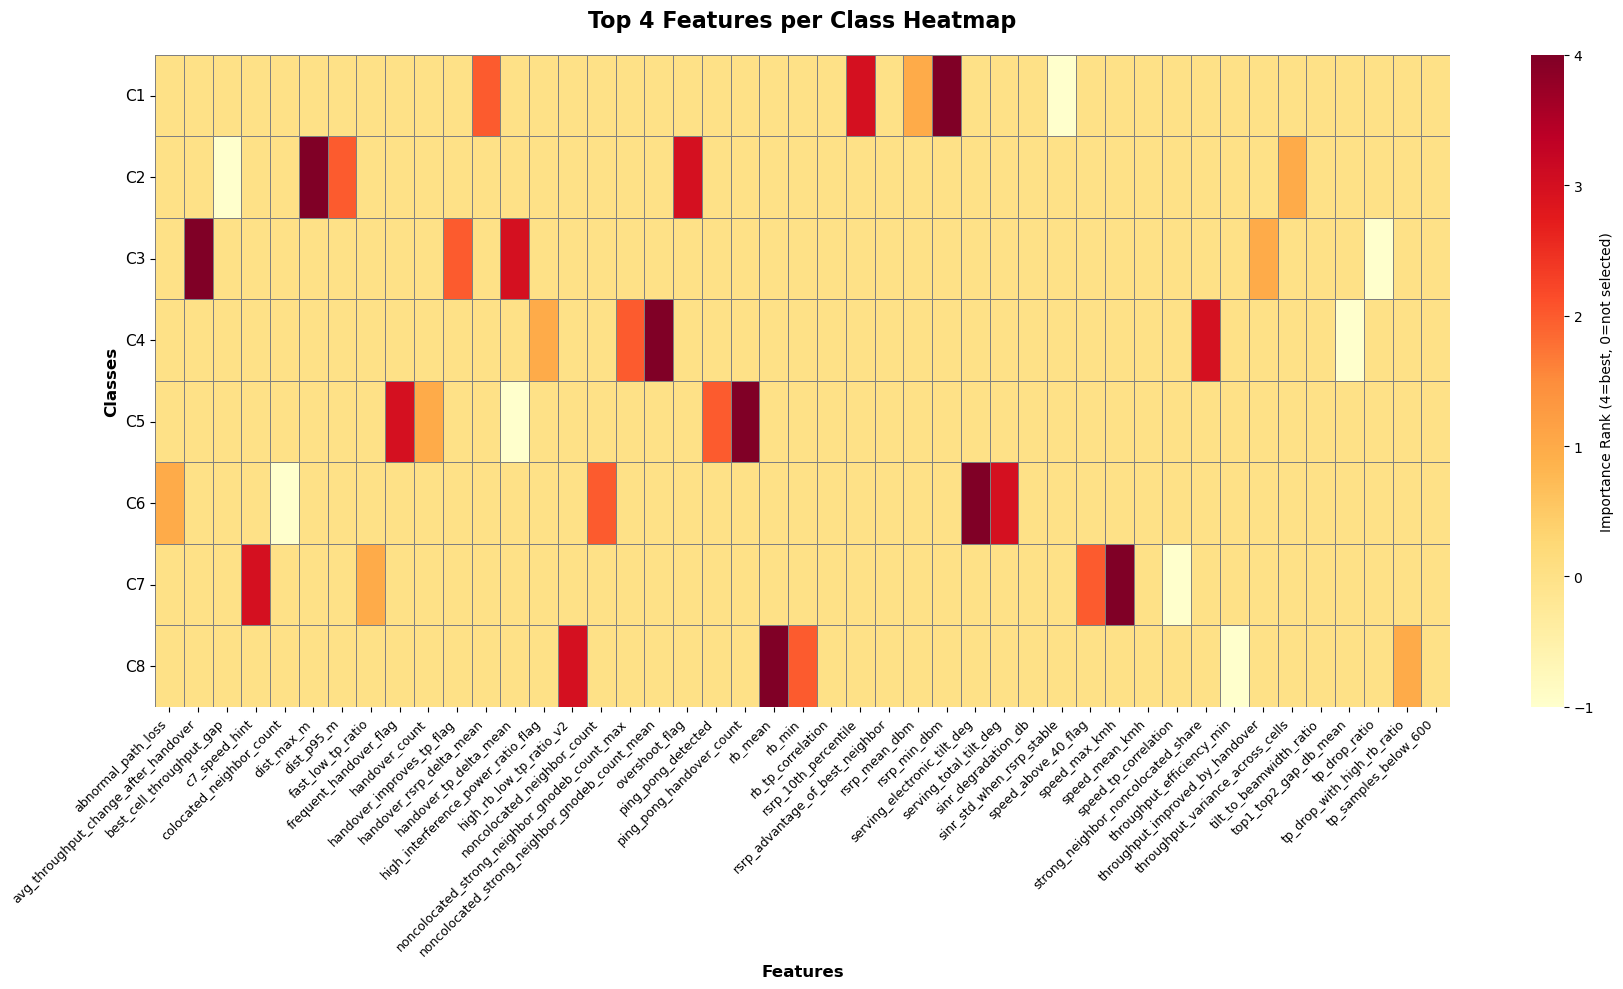

✅ Heatmap saved as: top_4_features_heatmap.png


In [119]:
# ============================================================================
# STEP 7: Visualization - Feature Heatmap
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("STEP 7: Visualizing Top 4 Features per Class")
print("="*80)

# Create a matrix: Classes × Features
classes_list = sorted(classes)
features_list = sorted(all_selected_features)

# Initialize matrix
matrix = np.zeros((len(classes_list), len(features_list)))

for i, cls in enumerate(classes_list):
    for j, feat in enumerate(features_list):
        if feat in top_4_per_class[cls]:
            # Get rank (1-4)
            rank = top_4_per_class[cls].index(feat) + 1
            matrix[i, j] = 5 - rank  # Inverted so rank 1 = 4, rank 4 = 1

# Create heatmap
fig, ax = plt.subplots(figsize=(max(16, len(features_list) * 0.4), 10))

sns.heatmap(
    matrix,
    xticklabels=features_list,
    yticklabels=classes_list,
    cmap='YlOrRd',
    cbar_kws={'label': 'Importance Rank (4=best, 0=not selected)'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

plt.title('Top 4 Features per Class Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Classes', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('top_4_features_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap saved as: top_4_features_heatmap.png")

In [109]:
# ============================================================================
# STEP 8: Export Final Top 4 Features Dataset
# ============================================================================

print("="*80)
print("STEP 8: Creating Optimized Dataset with Top 4 Features per Class")
print("="*80)

# Create the optimized dataset
features_df_top4 = features_df_enhanced[list(all_selected_features) + ['answer', 'id']].copy()

print(f"\nDataset created:")
print(f"  Original features: {len(feature_cols)}")
print(f"  Optimized features: {len(all_selected_features)}")
print(f"  Reduction: {(1 - len(all_selected_features)/len(feature_cols))*100:.1f}%")
print(f"  Shape: {features_df_top4.shape}")

# Save summary
summary = {
    'total_features': len(all_selected_features),
    'original_features': len(feature_cols),
    'reduction_percentage': (1 - len(all_selected_features)/len(feature_cols))*100,
    'accuracy_all_features': acc_all,
    'accuracy_top4': acc_union,
    'accuracy_difference': acc_union - acc_all,
    'f1_all_features': f1_all,
    'f1_top4': f1_union,
    'f1_difference': f1_union - f1_all,
}

print(f"\n{'='*80}")
print("SUMMARY METRICS")
print(f"{'='*80}")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key:<30s}: {value:.4f}")
    else:
        print(f"  {key:<30s}: {value}")

# Export
features_df_top4.to_csv('features_df_top4_per_class.csv', index=False)
print(f"\n✅ Optimized dataset saved as: features_df_top4_per_class.csv")

# Also save the feature list
with open('top_4_features_list.txt', 'w') as f:
    f.write("TOP 4 FEATURES PER CLASS\n")
    f.write("="*80 + "\n\n")
    for cls in sorted(classes):
        f.write(f"{cls}:\n")
        for i, feat in enumerate(top_4_per_class[cls], 1):
            f.write(f"  {i}. {feat}\n")
        f.write("\n")
    f.write(f"\nTotal unique features: {len(all_selected_features)}\n")
    f.write(f"\nAll selected features:\n")
    for feat in sorted(all_selected_features):
        usage = len([c for c, feats in top_4_per_class.items() if feat in feats])
        f.write(f"  • {feat} (used by {usage} class{'es' if usage > 1 else ''})\n")

print(f"✅ Feature list saved as: top_4_features_list.txt")

print(f"\n{'='*80}")
print("🎯 ANALYSIS COMPLETE!")
print(f"{'='*80}")
print(f"\nKey Findings:")
print(f"  • Identified top 4 features for each of the 8 classes")
print(f"  • Total unique features needed: {len(all_selected_features)}")
print(f"  • Feature reduction: {(1 - len(all_selected_features)/len(feature_cols))*100:.1f}%")
print(f"  • Performance maintained: {acc_union >= acc_all - 0.02}")
print(f"  • Accuracy: {acc_all:.4f} → {acc_union:.4f} ({acc_union-acc_all:+.4f})")
print(f"  • F1 Score: {f1_all:.4f} → {f1_union:.4f} ({f1_union-f1_all:+.4f})")
print(f"\n{'='*80}")

STEP 8: Creating Optimized Dataset with Top 4 Features per Class

Dataset created:
  Original features: 156
  Optimized features: 38
  Reduction: 75.6%
  Shape: (2400, 40)

SUMMARY METRICS
  total_features                : 38
  original_features             : 156
  reduction_percentage          : 75.6410
  accuracy_all_features         : 0.9958
  accuracy_top4                 : 0.9875
  accuracy_difference           : -0.0083
  f1_all_features               : 0.9958
  f1_top4                       : 0.9875
  f1_difference                 : -0.0084

✅ Optimized dataset saved as: features_df_top4_per_class.csv
✅ Feature list saved as: top_4_features_list.txt

🎯 ANALYSIS COMPLETE!

Key Findings:
  • Identified top 4 features for each of the 8 classes
  • Total unique features needed: 38
  • Feature reduction: 75.6%
  • Performance maintained: True
  • Accuracy: 0.9958 → 0.9875 (-0.0083)
  • F1 Score: 0.9958 → 0.9875 (-0.0084)

